# 1. Introduction et Objectifs

## Contexte Métier
L'attrition des employés est un problème courant en gestion des ressources humaines. Chaque départ non anticipé génère des coûts directs (recrutement, formation) et indirects (perte de productivité, impact sur l'équipe). Notre objectif est d'identifier **les patterns comportementaux et contextuels** qui prédisent les départs.

## Objectif du Modèle
- **Objectif Général** : Construire un modèle prédictif capable d'identifier les employés à risque de départ.
- **Objectif Actionnable** : Transformer les facteurs prédictifs en **3 à 5 recommandations RH concrètes** pour réduire l'attrition.

## Choix de la Métrique
**Pourquoi F1-Score et Recall plutôt qu'Accuracy ?**
- L'Accuracy est trompeuse : avec ~84% d'employés qui restent, un modèle naïf "prédisant toujours 'No Attrition'" atteindrait 84% sans valeur.
- **Recall** = Capacité à détecter les vrais départs (minimiser les faux négatifs). C'est critique : manquer un employé à risque = risque de perte réelle.
- **F1-Score** = Équilibre entre Precision (minimiser les fausses alertes) et Recall (détecter les vrais cas).
→ **Métrice retenue : F1-Score et Recall, validées en Cross-Validation Stratifiée.**

In [86]:
# ============================================================================
# 2. CHARGEMENT ET APERÇU DES DONNÉES
# ============================================================================

# Importation des bibliothèques essentielles
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import warnings
import time
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_predict, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
    classification_report, balanced_accuracy_score, roc_auc_score, matthews_corrcoef,
    average_precision_score, brier_score_loss, auc, roc_curve, precision_recall_curve
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.decomposition import PCA

# Configuration pour les visualisations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

In [89]:
# Chargement des datasets train et test préparés
# Ces datasets ont été prétraités par preparation.ipynb : normalisation, encodage, suppression des fuites
df_train = pd.read_csv('prepared_dataset_train.csv')
df_test = pd.read_csv('prepared_dataset_test.csv')

print("="*70)
print("APERÇU DE LA STRUCTURE DES DONNÉES")
print("="*70)

print(f"\n📊 Shape du dataset d'entraînement  : {df_train.shape}")
print(f"📊 Shape du dataset de validation  : {df_test.shape}")

# Détection automatique de la colonne cible
target_candidates = ['Attrition_Yes', 'Attrition']
target_col = next((c for c in target_candidates if c in df_train.columns), None)
if target_col is None:
    raise ValueError(f"Colonne cible introuvable. Colonnes attendues: {target_candidates}")

# Séparation X (features) et y (target)
X_train = df_train.drop(columns=[target_col])
y_train = df_train[target_col].astype(float)

X_valid = df_test.drop(columns=[target_col])
y_valid = df_test[target_col].astype(float)

# Combinaison pour analyses globales
X = pd.concat([X_train, X_valid], axis=0).reset_index(drop=True)
y = pd.concat([y_train, y_valid], axis=0).reset_index(drop=True)
df = pd.concat([df_train, df_test], axis=0).reset_index(drop=True)

print(f"\n📈 Ensemble d'entraînement   : {X_train.shape[0]:,d} employés")
print(f"📈 Ensemble de validation   : {X_valid.shape[0]:,d} employés")
print(f"📈 Total                     : {X.shape[0]:,d} employés\n")

# Vérification du déséquilibre de classe (critère clé pour notre métrique)
print("Distribution de la variable cible (Attrition):")
print(y_train.value_counts(normalize=True).round(4))

attrition_rate = y_train.mean() * 100
print(f"\n⚠️  Taux d'attrition en train   : {attrition_rate:.2f}%")
print(f"⚠️  Taux de rétention en train   : {100-attrition_rate:.2f}%")
print(f"→ Le dataset est DÉSÉQUILIBRÉ (peu de départs). Cela justifie l'usage de")
print(f"  class_weight='balanced' et la validation croisée stratifiée.")

APERÇU DE LA STRUCTURE DES DONNÉES

📊 Shape du dataset d'entraînement  : (3528, 42)
📊 Shape du dataset de validation  : (882, 42)

📈 Ensemble d'entraînement   : 3,528 employés
📈 Ensemble de validation   : 882 employés
📈 Total                     : 4,410 employés

Distribution de la variable cible (Attrition):
Attrition_Yes
0.0    0.8387
1.0    0.1613
Name: proportion, dtype: float64

⚠️  Taux d'attrition en train   : 16.13%
⚠️  Taux de rétention en train   : 83.87%
→ Le dataset est DÉSÉQUILIBRÉ (peu de départs). Cela justifie l'usage de
  class_weight='balanced' et la validation croisée stratifiée.


# 2. Chargement et Aperçu des Données

## Qu'allons-nous faire ?
1. Charger les datasets train/test préparés par `preparation.ipynb`
2. Vérifier la structure (shape, types) et le déséquilibre de classe
3. Confirmer que NO data leakage n'a été introduit

## Points Clés
- Les features ont été **normalisées (scaling) et encodées (one-hot)** lors de la préparation
- Le scaling n'est PAS appliqué globalement pour éviter les fuites : chaque pipeline intègre son propre `StandardScaler`
- Le dataset cible est **déséquilibré** (~84% rétention, ~16% attrition) → Justifie le choix de métriques (F1, Recall) et de stratégies comme `class_weight='balanced'`

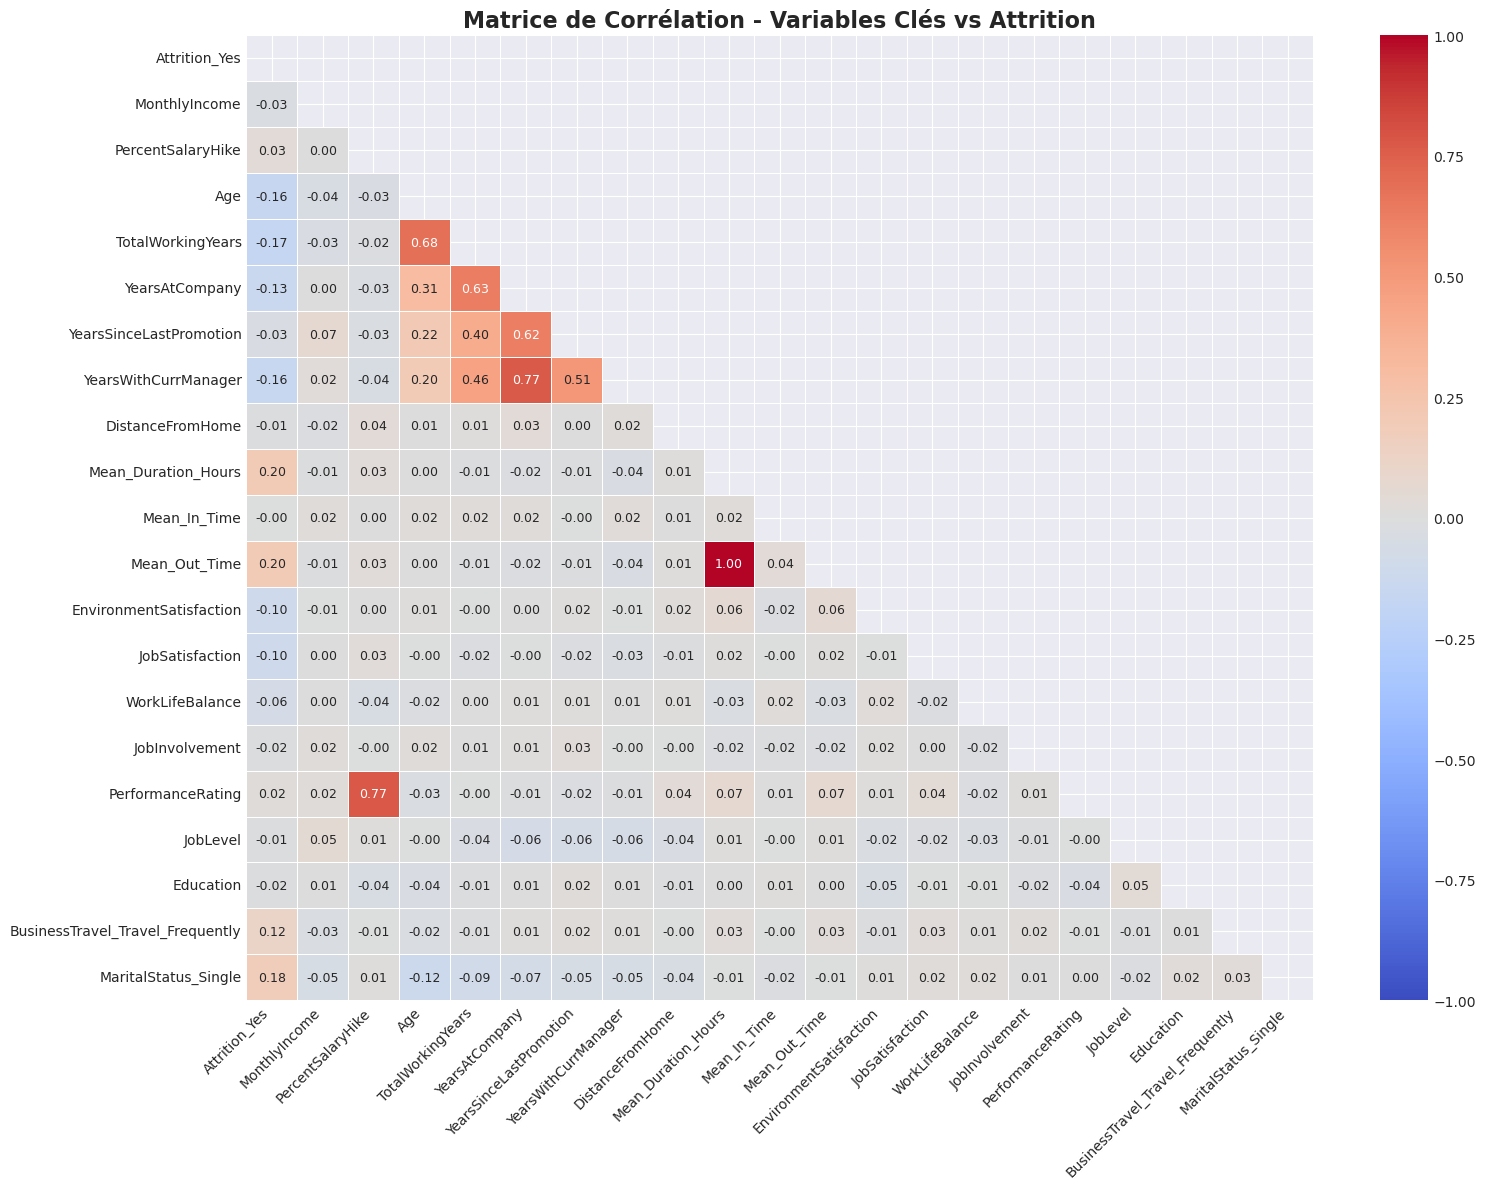


📊 Top Corrélations avec l'Attrition:
Attrition_Yes                       1.000000
Mean_Duration_Hours                 0.201191
Mean_Out_Time                       0.201099
MaritalStatus_Single                0.175419
BusinessTravel_Travel_Frequently    0.115143
PercentSalaryHike                   0.032533
PerformanceRating                   0.023403
Mean_In_Time                       -0.000881
DistanceFromHome                   -0.009730
JobLevel                           -0.010290


In [90]:
# Matrice de corrélation limitée aux variables clés
# Cette approche rend la matrice lisible en excluant les dummies peu pertinentes

cols_to_correlate = [
    target_col,  # La cible (Attrition_Yes)
    
    # Variables Numériques Continues
    'MonthlyIncome', 'PercentSalaryHike', 'Age', 
    'TotalWorkingYears', 'YearsAtCompany', 'YearsSinceLastPromotion', 
    'YearsWithCurrManager', 'DistanceFromHome',
    'Mean_Duration_Hours', 'Mean_In_Time', 'Mean_Out_Time',
    
    # Variables Ordinales
    'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance',
    'JobInvolvement', 'PerformanceRating', 'JobLevel', 'Education',
    
    # Dummies stratégiques
    'BusinessTravel_Travel_Frequently', 'MaritalStatus_Single'
]

# Filtrage : ne garder que les colonnes existantes
existing_cols = [c for c in cols_to_correlate if c in df.columns]

# Création de la matrice
corr_matrix = df[existing_cols].corr()

# Masque du triangle supérieur pour plus de clarté
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Visualisation
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f', 
    linewidths=0.5,
    vmin=-1, 
    vmax=1,
    annot_kws={"size": 9}
)
plt.title('Matrice de Corrélation - Variables Clés vs Attrition', fontsize=16, weight='bold')
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Extraction des corrélations avec la cible pour identifier les facteurs clés
corr_with_target = corr_matrix[target_col].sort_values(ascending=False)
print("\n📊 Top Corrélations avec l'Attrition:")
print(corr_with_target.head(10).to_string())


FACTEUR CLÉ #1 : REVENU MENSUEL
Hypothèse : Un salaire plus bas augmente le risque de départ
(Les employés sous-payés cherchent des opportunités ailleurs)


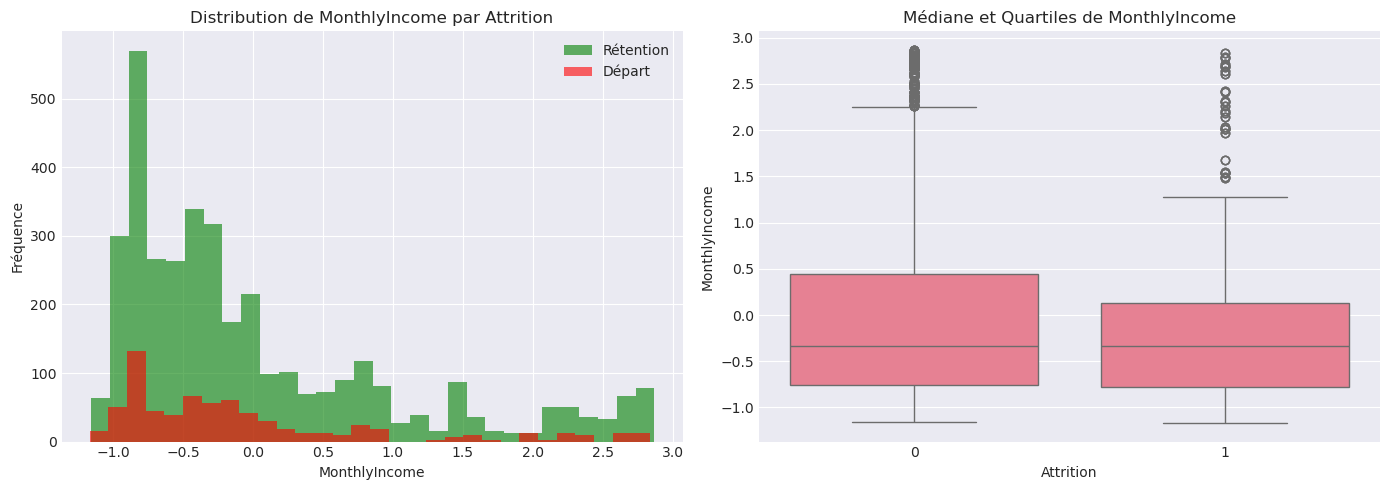


📊 Statistiques par groupe:
                count  mean   std   min   25%   50%   75%   max
Attrition_Yes                                                  
0              3699.0  0.01  1.01 -1.16 -0.76 -0.33  0.45  2.87
1               711.0 -0.07  0.95 -1.17 -0.78 -0.34  0.13  2.84


In [95]:
# Fonction utility pour créer les plots récursifs
def plot_attrition_relation(df, column, target_col, plot_type='distribution'):
    """
    Visualise la relation entre une variable et l'attrition.
    
    Args:
        df (pd.DataFrame): Dataset
        column (str): Colonne à analyzer
        target_col (str): Colonne cible (Attrition_Yes)
        plot_type (str): 'distribution', 'boxplot', ou 'bar'
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    if plot_type == 'distribution':
        # Histogramme avec séparation par attrition
        df[df[target_col] == 0][column].hist(bins=30, ax=ax1, alpha=0.6, label='Rétention', color='green')
        df[df[target_col] == 1][column].hist(bins=30, ax=ax1, alpha=0.6, label='Départ', color='red')
        ax1.set_xlabel(column)
        ax1.set_ylabel('Fréquence')
        ax1.set_title(f'Distribution de {column} par Attrition')
        ax1.legend()
        
        # Boîte à moustaches pour voir les différences
        sns.boxplot(data=df, x=target_col, y=column, ax=ax2)
        ax2.set_xlabel('Attrition')
        ax2.set_ylabel(column)
        ax2.set_title(f'Médiane et Quartiles de {column}')

    elif plot_type == 'bar':
        # Tableau croisé pour variables categoriques
        cross_tab = pd.crosstab(df[column], df[target_col], normalize='index') * 100
        cross_tab.plot(kind='bar', ax=ax1, color=['green', 'red'], alpha=0.7)
        ax1.set_title(f'Taux de Départ par Catégorie de {column}')
        ax1.set_xlabel(column)
        ax1.set_ylabel('Pourcentage (%)')
        ax1.legend(['Rétention', 'Départ'])
        ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
        
        # Compte absolu
        cross_tab_count = pd.crosstab(df[column], df[target_col])
        cross_tab_count.plot(kind='bar', ax=ax2, color=['green', 'red'], alpha=0.7)
        ax2.set_title(f'Nombre de Départs par Catégorie')
        ax2.set_xlabel(column)
        ax2.set_ylabel('Nombre')
        ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)
        ax2.legend(['Rétention', 'Départ'])

    plt.tight_layout()
    plt.show()


# 🎯 Plot 1 : Relation entre le Revenu Mensuel et le Départ
print("\n" + "="*70)
print("FACTEUR CLÉ #1 : REVENU MENSUEL")
print("="*70)
print("Hypothèse : Un salaire plus bas augmente le risque de départ")
print("(Les employés sous-payés cherchent des opportunités ailleurs)")

plot_attrition_relation(df, 'MonthlyIncome', target_col, plot_type='distribution')

# Statistiques
print("\n📊 Statistiques par groupe:")
print(df.groupby(target_col)['MonthlyIncome'].describe().round(2))


FACTEUR CLÉ #2 : ÉQUILIBRE VIE PROFESSIONNELLE / VIE PRIVÉE
Hypothèse : Une mauvaise satisfaction work-life-balance pousse au départ
(Les employés surmenés cherchent une meilleure qualité de vie)


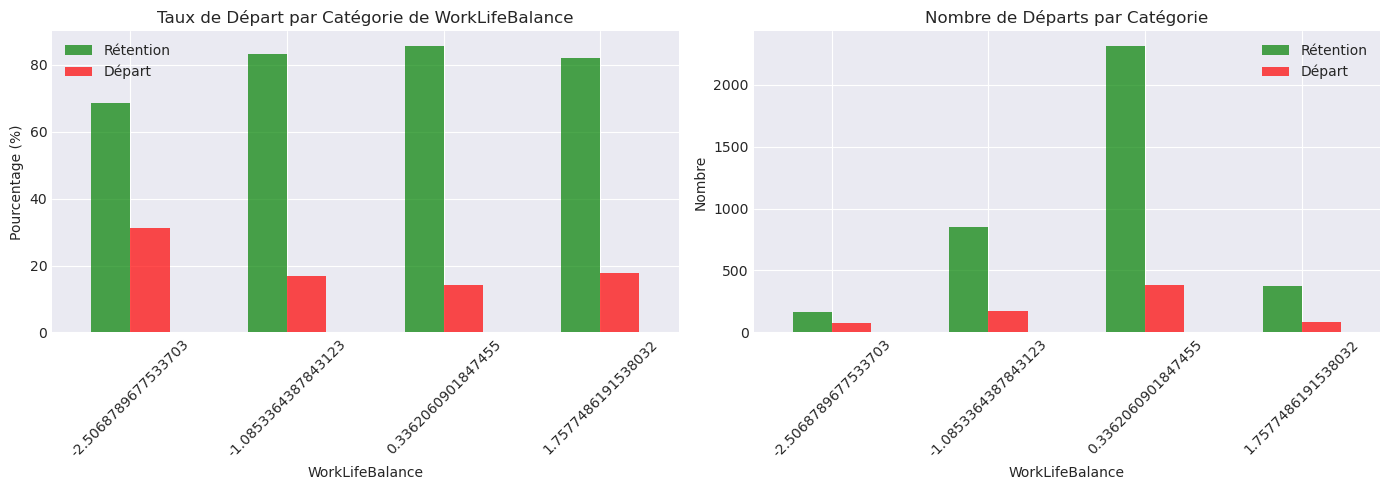


📊 Crosstab Work-Life Balance vs Attrition:
Attrition_Yes       0    1   All
WorkLifeBalance                 
-2.506879         164   75   239
-1.085336         848  171  1019
 0.336206        2314  384  2698
 1.757749         373   81   454
 All             3699  711  4410


In [92]:
# 🎯 Plot 2 : Impact de l'Équilibre Vie Pro / Vie Perso
print("\n" + "="*70)
print("FACTEUR CLÉ #2 : ÉQUILIBRE VIE PROFESSIONNELLE / VIE PRIVÉE")
print("="*70)
print("Hypothèse : Une mauvaise satisfaction work-life-balance pousse au départ")
print("(Les employés surmenés cherchent une meilleure qualité de vie)")

if 'WorkLifeBalance' in df.columns:
    plot_attrition_relation(df, 'WorkLifeBalance', target_col, plot_type='bar')
    
    print("\n📊 Crosstab Work-Life Balance vs Attrition:")
    ct = pd.crosstab(df['WorkLifeBalance'], df[target_col], margins=True)
    print(ct)
else:
    print("⚠️  WorkLifeBalance non trouvée dans le dataset.")


FACTEUR CLÉ #3a : ANCIENNETÉ DANS L'ENTREPRISE
Hypothèse : Les nouveaux employés sont plus vulnerables au départ
(Période d'adaptation, moins d'engagement, opportunités extérieures attrayantes)


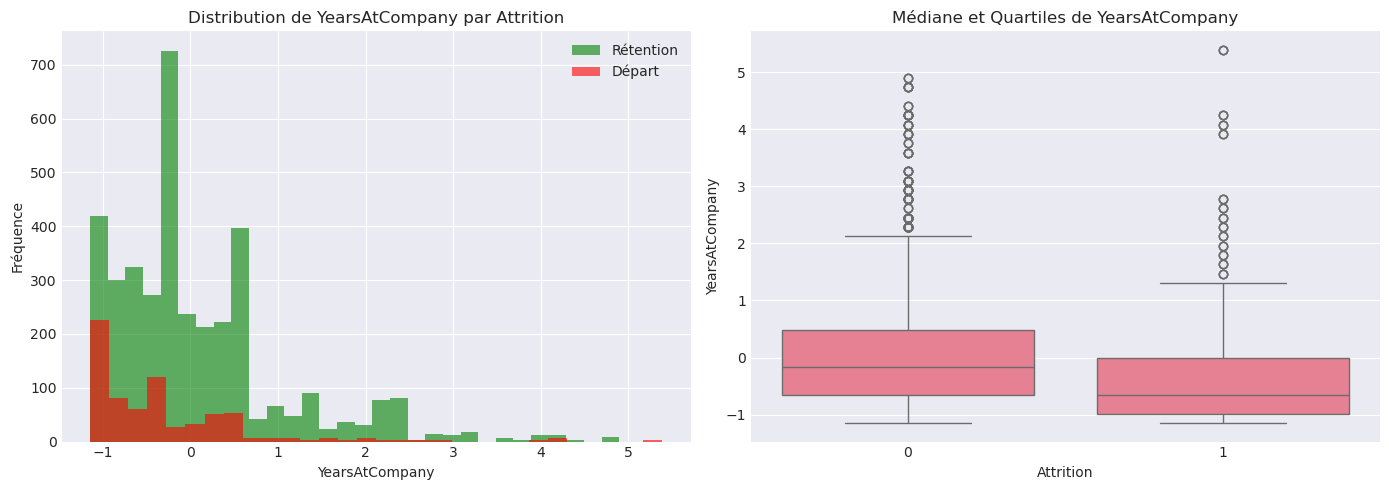


📊 Statistiques par groupe:
                count  mean   std   min   25%   50%   75%   max
Attrition_Yes                                                  
0              3699.0  0.06  1.00 -1.14 -0.65 -0.16  0.49  4.90
1               711.0 -0.31  0.97 -1.14 -0.98 -0.65 -0.00  5.39

FACTEUR CLÉ #3b : ANCIENNETÉ AVEC LE MANAGER ACTUEL
Hypothèse : Un manager stable (relation longue) réduit les départs
(Les changements fréquents de manager créent de l'instabilité)


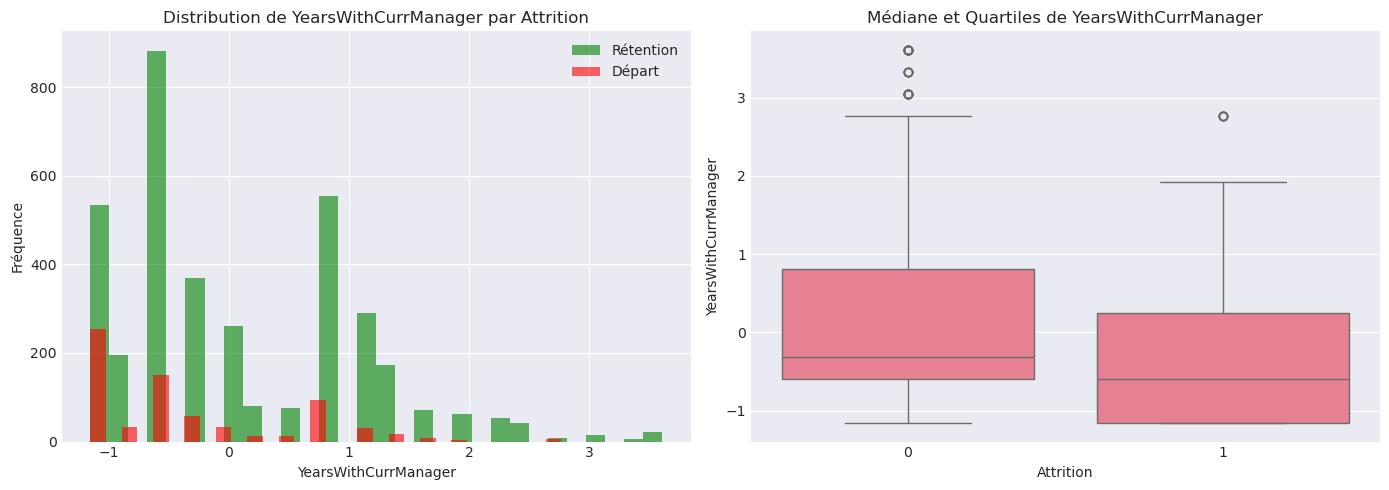


📊 Statistiques par groupe:
                count  mean   std   min   25%   50%   75%   max
Attrition_Yes                                                  
0              3699.0  0.07  1.01 -1.16 -0.60 -0.31  0.81  3.61
1               711.0 -0.36  0.88 -1.16 -1.16 -0.60  0.25  2.77


In [93]:
# 🎯 Plot 3 : Impact de l'Ancienneté et de la Relation au Management
print("\n" + "="*70)
print("FACTEUR CLÉ #3a : ANCIENNETÉ DANS L'ENTREPRISE")
print("="*70)
print("Hypothèse : Les nouveaux employés sont plus vulnerables au départ")
print("(Période d'adaptation, moins d'engagement, opportunités extérieures attrayantes)")

if 'YearsAtCompany' in df.columns:
    plot_attrition_relation(df, 'YearsAtCompany', target_col, plot_type='distribution')
    
    print("\n📊 Statistiques par groupe:")
    print(df.groupby(target_col)['YearsAtCompany'].describe().round(2))
else:
    print("⚠️  YearsAtCompany non trouvée dans le dataset.")

print("\n" + "="*70)
print("FACTEUR CLÉ #3b : ANCIENNETÉ AVEC LE MANAGER ACTUEL")
print("="*70)
print("Hypothèse : Un manager stable (relation longue) réduit les départs")
print("(Les changements fréquents de manager créent de l'instabilité)")

if 'YearsWithCurrManager' in df.columns:
    plot_attrition_relation(df, 'YearsWithCurrManager', target_col, plot_type='distribution')
    
    print("\n📊 Statistiques par groupe:")
    print(df.groupby(target_col)['YearsWithCurrManager'].describe().round(2))
else:
    print("⚠️  YearsWithCurrManager non trouvée dans le dataset.")

### 📋 Résumé de l'EDA - Hypothèses Identifiées

D'après l'analyse exploratoire, les facteurs clés de départ semblent être :

1. **Revenu Mensuel** : Un salaire bas augmente le risque de départ
2. **Équilibre Vie Pro/Perso** : Une mauvaise satisfaction créé de l'instabilité
3. **Ancienneté en Entreprise & avec le Manager** : Les nouveaux employés et ceux ayant changé de manager sont plus à risque
4. **Autres facteurs** : À découvrir via Feature Importance et SHAP après modélisation

→ **Prochainement** : Les modèles ML vont **quantifier** et **valider** ces patterns.

# 3. Analyse Exploratoire (EDA) & Corrélations

## Qu'allons-nous faire ?
1. Identifier les variables les plus fortement corrélées avec l'attrition
2. Visualiser les facteurs clés de départ (revenu, équilibre work-life, ancienneté, management)
3. Formuler des **hypothèses métier** pour les étapes suivantes

## Logique
- L'**EDA guide la modélisation** : Les variables corrélées aux départs sont les leviers d'action.
- On ignore les variables à faible variance (déjà filtrées en préparation).
- On cherche des **patterns non-linéaires** : D'où l'intérêt de modèles ensemblistes (Random Forest, XGBoost).

# 4. Stratégie de Modélisation & Prétraitement

## Pipeline : Comment prévenir les fuites de données ?

### Approche 1 : Scaling + Encodage Globaux ❌ (MAUVAIS)
```
StandardScaler(données brutes) → One-Hot Encoding → Train/Test Split → Modèle
```
→ **Problème** : Le scaler a vu TOUTES les données (train+test), introduisant une fuite.

### Approche 2 : Pipelines avec Scaling Interne ✅ (BON)
```
Train/Test Split → [Scaler + Encodeur] dans le Pipeline → Fit sur train → Prédiction sur test
```
→ **Avantage** : Le scaler de chaque pipeline ne voit QUE les données d'entraînement.

## Gestion du Déséquilibre

Le dataset contient ~84% de rétention et ~16% de départ.

**Stratégie** : `class_weight='balanced'` 
- Augmente le coût des erreurs sur la classe minoritaire (départs)
- Réduit le biais naturaldu modèle vers la classe majority
- Évite le "bruit" de la surreprésentation

## Validation Stratifiée

On utilise `StratifiedKFold` plutôt que `KFold` pour s'assurer que :
- Chaque fold respecte la proportion 84/16
- Les résultats cross-val sont stables et représentatifs

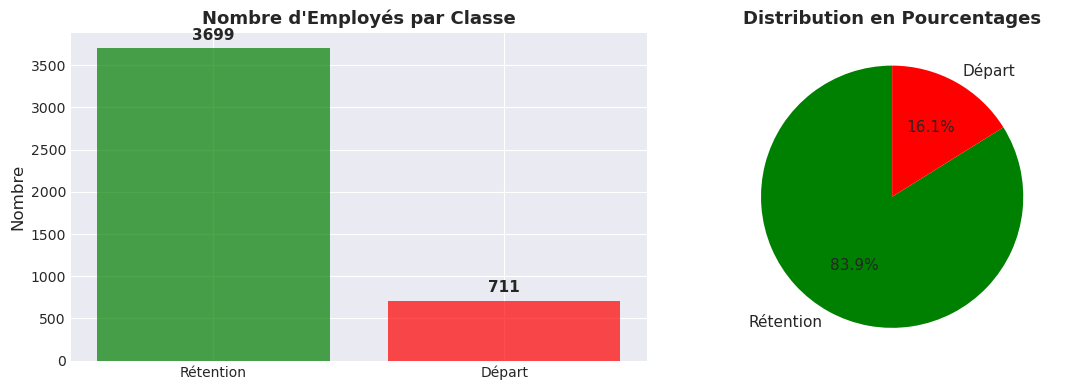


✅ Ce déséquilibre JUSTIFIE l'utilisation de métriques au-delà de l'Accuracy.
   → On optimise sur F1-Score et Recall, validés en StratifiedKFold.


In [94]:
# Distribution visuelle du déséquilibre
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Compte absolu
counts = df[target_col].value_counts()
ax1.bar(['Rétention', 'Départ'], counts.values, color=['green', 'red'], alpha=0.7)
ax1.set_ylabel('Nombre', fontsize=12)
ax1.set_title('Nombre d\'Employés par Classe', fontsize=13, weight='bold')
for i, (label, val) in enumerate(zip(['Rétention', 'Départ'], counts.values)):
    ax1.text(i, val + 100, str(val), ha='center', fontsize=11, weight='bold')

# Pourcentage
percentages = (counts / counts.sum() * 100).values
colors_pie = ['green', 'red']
ax2.pie(percentages, labels=['Rétention', 'Départ'], autopct='%1.1f%%', 
        colors=colors_pie, startangle=90, textprops={'fontsize': 11})
ax2.set_title('Distribution en Pourcentages', fontsize=13, weight='bold')

plt.tight_layout()
plt.show()

print("\n✅ Ce déséquilibre JUSTIFIE l'utilisation de métriques au-delà de l'Accuracy.")
print("   → On optimise sur F1-Score et Recall, validés en StratifiedKFold.")

Corrélation avec l'Attrition:
Mean_Duration_Hours                 0.201191
Mean_Out_Time                       0.201099
MaritalStatus_Single                0.175419
TotalWorkingYears                  -0.170162
Age                                -0.159205
YearsWithCurrManager               -0.156199
YearsAtCompany                     -0.134392
BusinessTravel_Travel_Frequently    0.115143
JobSatisfaction                    -0.104017
EnvironmentSatisfaction            -0.101625
dtype: float64


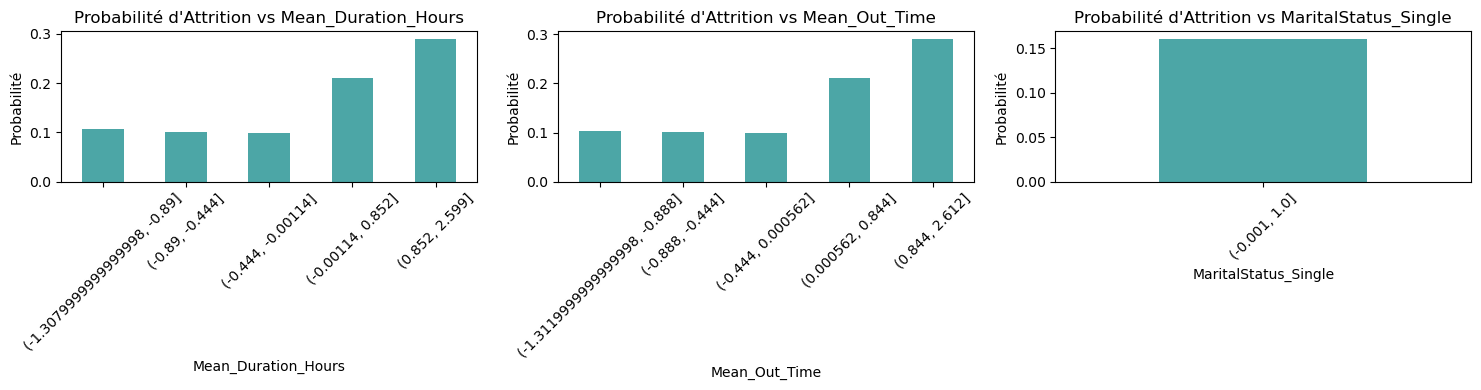

In [ ]:
# Brique 8 - Relations entre les variables et la cible (Probabilité d'attrition)

# Variables numériques intéressantes potentielles (par ex. Age, DistanceFromHome, MonthlyIncome)
numeric_cols = df.select_dtypes(include='number').columns.drop(target_col, errors='ignore')
corr_with_target = df[numeric_cols].apply(lambda x: x.corr(df[target_col]))

print("Corrélation avec l'Attrition:")
print(corr_with_target.sort_values(key=abs, ascending=False).head(10))

# Visualisons l'attrition par rapport à une ou deux variables les plus corrélées
top_corr_vars = corr_with_target.sort_values(key=abs, ascending=False).index[:3]
fig, axes = plt.subplots(1, len(top_corr_vars), figsize=(15, 4))
for i, var in enumerate(top_corr_vars):
    # Regrouper en tranches (bins) pour estimer la probabilité
    bins = pd.qcut(df[var], q=5, duplicates='drop')
    prob_attrition = df.groupby(bins, observed=False)[target_col].mean()
    
    prob_attrition.plot(kind='bar', ax=axes[i], color='teal', alpha=0.7)
    axes[i].set_title(f"Probabilité d'Attrition vs {var}")
    axes[i].set_ylabel("Probabilité")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Brique 9 - Pipeline de Préparation et Régression Logistique (80/20)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, auc,
    classification_report
)

# Note : On conserve nos sets 'X_train' et 'X_valid' importés depuis nos datasets séparés au début du document.
# Le ré-échantillonnage n'est plus utile ici.

# Pipeline: Normalisation -> Régression Logistique
pipeline_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)) 
    # use class_weight='balanced' especially due to class imbalance seen in linear model recall
])

print("Entraînement de la Régression Logistique...")
pipeline_logreg.fit(X_train, y_train)

# Prédictions sur la validation
y_pred_proba = pipeline_logreg.predict_proba(X_valid)[:, 1] # probabilité de la classe 1
y_pred_logreg = pipeline_logreg.predict(X_valid)

# Indicateurs de base
acc = accuracy_score(y_valid, y_pred_logreg)
prec = precision_score(y_valid, y_pred_logreg)
rec = recall_score(y_valid, y_pred_logreg)
f1 = f1_score(y_valid, y_pred_logreg)

print(f"\nPerformances sur l'échantillon de validation (N={len(y_valid)}):")
print(f"Accuracy  : {acc:.4f}")
print(f"Précision : {prec:.4f}")
print(f"Rappel    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")
print("\nRapport de métriques Détaillé:\n", classification_report(y_valid, y_pred_logreg))

Entraînement de la Régression Logistique...

Performances sur l'échantillon de validation (N=882):
Accuracy  : 0.7710
Précision : 0.3872
Rappel    : 0.7254
F1-score  : 0.5049

Rapport de métriques Détaillé:
               precision    recall  f1-score   support

         0.0       0.94      0.78      0.85       740
         1.0       0.39      0.73      0.50       142

    accuracy                           0.77       882
   macro avg       0.66      0.75      0.68       882
weighted avg       0.85      0.77      0.80       882



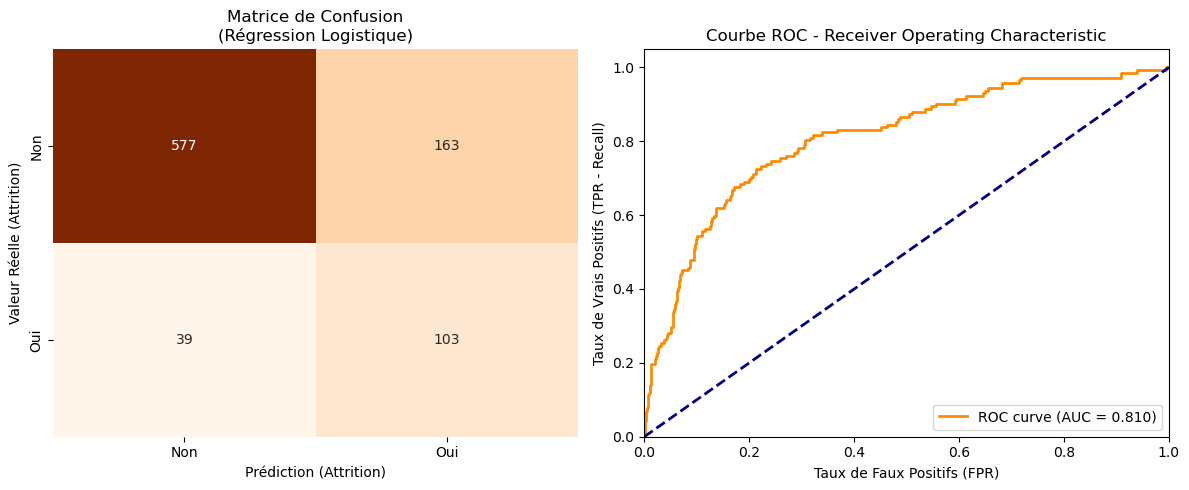

In [ ]:
# Brique 10 - Matrice de Confusion et Courbe ROC / AUC
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 1. Matrice de Confusion
cm_logreg = confusion_matrix(y_valid, y_pred_logreg)
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=ax1,
            xticklabels=['Non', 'Oui'], yticklabels=['Non', 'Oui'])
ax1.set_title("Matrice de Confusion\n(Régression Logistique)")
ax1.set_xlabel("Prédiction (Attrition)")
ax1.set_ylabel("Valeur Réelle (Attrition)")

# 2. Courbe ROC
fpr, tpr, thresholds = roc_curve(y_valid, y_pred_proba)
roc_auc = auc(fpr, tpr)

ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Taux de Faux Positifs (FPR)')
ax2.set_ylabel('Taux de Vrais Positifs (TPR - Recall)')
ax2.set_title("Courbe ROC - Receiver Operating Characteristic")
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

# 5. Comparaison des Modèles (Benchmark)

## Qu'allons-nous faire ?
1. Entraîner rapidement **6-7 modèles simples** (baselines)
2. Les évaluer sur train/test avec StratifiedKFold
3. Identifier le **champion** = celui avec le meilleur F1-Score
4. Préparer le terrain pour l'optimisation hyperparamètres

## Modèles Testés
- **Régression Logistique** : Modèle linéaire, interprétable, rapide
- **Arbre de Décision** : Capture des non-linéarités simples
- **K-Nearest Neighbors (KNN)** : Approche basée sur la proximité
- **Support Vector Machine (SVM)** : Frontière non-linéaire via kernel trick
- **Naive Bayes** : Approche probabiliste
- **Random Forest** : Ensemble d'arbres, réduit overfitting
- **Gradient Boosting** : Ensemble séquentiel, puissant

→ **Métrique Clé** : F1-Score (équilibre Precision/Recall) validé en **StratifiedKFold 5-fold**

---

## 5a. Modèle de Classification : Régression Logistique

La régression logistique est le modèle linéaire de référence. Elle est interprétable et pose la baseline.

## 5a. Modèle de Classification : Régression Logistique

**Description** : Modèle linéaire probabiliste, interprétable, rapide.

**Paramètres Utilisés** :
- `max_iter=1000` : Nombre d'itérations d'optimisation. Plus élevé = plus précis mais plus lent
- `class_weight='balanced'` : Pénalise les erreurs sur la classe minoritaire (départs), équilibre l'importance des classes
- `random_state=42` : Fixe la graine aléatoire pour reproductibilité

**Quand l'utiliser** : Bonne baseline, résultats explicables facilement

In [ ]:
# Brique 11 - Pipeline et Entraînement de l'Arbre de Décision (80/20)

from sklearn.tree import DecisionTreeClassifier

# Pipeline: Normalisation -> Arbre de Décision
# Note : L'arbre de décision n'a pas strictement besoin d'une normalisation, mais nous gardons le StandardScaler 
# pour rester cohérents par rapport à la pipeline précédente.
pipeline_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('dt', DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)) 
    # Profondeur limitée (5) pour éviter un surapprentissage excessif (overfitting)
])

print("Entraînement de l'Arbre de Décision...")
pipeline_dt.fit(X_train, y_train)

# Prédictions sur la validation
y_pred_proba_dt = pipeline_dt.predict_proba(X_valid)[:, 1] # probabilité de la classe 1
y_pred_dt = pipeline_dt.predict(X_valid)

# Indicateurs de base
acc_dt = accuracy_score(y_valid, y_pred_dt)
prec_dt = precision_score(y_valid, y_pred_dt)
rec_dt = recall_score(y_valid, y_pred_dt)
f1_dt = f1_score(y_valid, y_pred_dt)

print(f"\nPerformances de l'Arbre sur l'échantillon de validation (N={len(y_valid)}):")
print(f"Accuracy  : {acc_dt:.4f}")
print(f"Précision : {prec_dt:.4f}")
print(f"Rappel    : {rec_dt:.4f}")
print(f"F1-score  : {f1_dt:.4f}")
print("\nRapport de métriques Détaillé:\n", classification_report(y_valid, y_pred_dt))

Entraînement de l'Arbre de Décision...

Performances de l'Arbre sur l'échantillon de validation (N=882):
Accuracy  : 0.7846
Précision : 0.4032
Rappel    : 0.7042
F1-score  : 0.5128

Rapport de métriques Détaillé:
               precision    recall  f1-score   support

         0.0       0.93      0.80      0.86       740
         1.0       0.40      0.70      0.51       142

    accuracy                           0.78       882
   macro avg       0.67      0.75      0.69       882
weighted avg       0.85      0.78      0.81       882



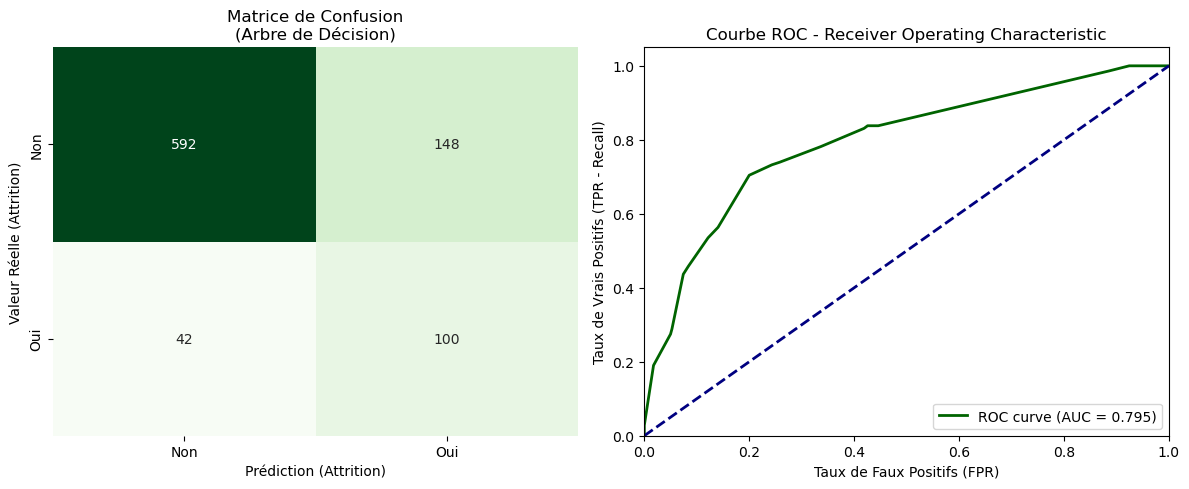

In [ ]:
# Brique 12 - Matrice de Confusion et Courbe ROC / AUC (Arbre de Décision)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 1. Matrice de Confusion
cm_dt = confusion_matrix(y_valid, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', cbar=False, ax=ax1,
            xticklabels=['Non', 'Oui'], yticklabels=['Non', 'Oui'])
ax1.set_title("Matrice de Confusion\n(Arbre de Décision)")
ax1.set_xlabel("Prédiction (Attrition)")
ax1.set_ylabel("Valeur Réelle (Attrition)")

# 2. Courbe ROC
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_valid, y_pred_proba_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

ax2.plot(fpr_dt, tpr_dt, color='darkgreen', lw=2, label=f'ROC curve (AUC = {roc_auc_dt:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Taux de Faux Positifs (FPR)')
ax2.set_ylabel('Taux de Vrais Positifs (TPR - Recall)')
ax2.set_title("Courbe ROC - Receiver Operating Characteristic")
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

## 5c. Modèle de Classification : K-Nearest Neighbors (KNN)

**Description** : Classifie selon les K voisins les plus proches. Non-paramétrique = adaptatif aux données.

**Paramètres Utilisés** :
- `n_neighbors=5` : Nombre de voisins (petit = local/sensible, grand = global/stable)
- `weights='distance'` : Pèse les voisins par distance (proches = plus influents)

**Quand l'utiliser** : Quand les données ont structure locale claire. Attention : peut être lent sur données larges.

In [ ]:
# Brique 14 - Pipeline et Entraînement KNN (80/20)

from sklearn.neighbors import KNeighborsClassifier

# Pipeline: Normalisation -> KNN
# La normalisation est CRUCIALE pour KNN car il se base sur la distance spatiale
pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5, weights='distance'))
])

print("Entraînement du modèle K-Nearest Neighbors...")
pipeline_knn.fit(X_train, y_train)

# Prédictions sur la validation
y_pred_proba_knn = pipeline_knn.predict_proba(X_valid)[:, 1] # probabilité de la classe 1
y_pred_knn = pipeline_knn.predict(X_valid)

# Indicateurs de base
acc_knn = accuracy_score(y_valid, y_pred_knn)
prec_knn = precision_score(y_valid, y_pred_knn)
rec_knn = recall_score(y_valid, y_pred_knn)
f1_knn = f1_score(y_valid, y_pred_knn)

print(f"\nPerformances du KNN sur l'échantillon de validation (N={len(y_valid)}):")
print(f"Accuracy  : {acc_knn:.4f}")
print(f"Précision : {prec_knn:.4f}")
print(f"Rappel    : {rec_knn:.4f}")
print(f"F1-score  : {f1_knn:.4f}")
print("\nRapport de métriques Détaillé:\n", classification_report(y_valid, y_pred_knn))

Entraînement du modèle K-Nearest Neighbors...

Performances du KNN sur l'échantillon de validation (N=882):
Accuracy  : 0.9717
Précision : 0.9756
Rappel    : 0.8451
F1-score  : 0.9057

Rapport de métriques Détaillé:
               precision    recall  f1-score   support

         0.0       0.97      1.00      0.98       740
         1.0       0.98      0.85      0.91       142

    accuracy                           0.97       882
   macro avg       0.97      0.92      0.94       882
weighted avg       0.97      0.97      0.97       882



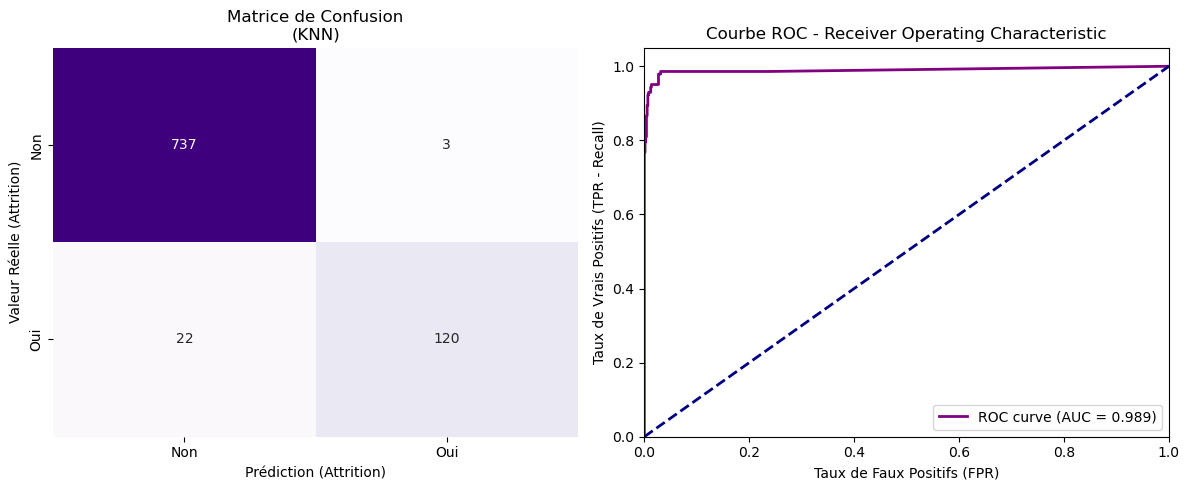

In [ ]:
# Brique 15 - Matrice de Confusion et Courbe ROC / AUC (KNN)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 1. Matrice de Confusion
cm_knn = confusion_matrix(y_valid, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Purples', cbar=False, ax=ax1,
            xticklabels=['Non', 'Oui'], yticklabels=['Non', 'Oui'])
ax1.set_title("Matrice de Confusion\n(KNN)")
ax1.set_xlabel("Prédiction (Attrition)")
ax1.set_ylabel("Valeur Réelle (Attrition)")

# 2. Courbe ROC
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_valid, y_pred_proba_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)

ax2.plot(fpr_knn, tpr_knn, color='purple', lw=2, label=f'ROC curve (AUC = {roc_auc_knn:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Taux de Faux Positifs (FPR)')
ax2.set_ylabel('Taux de Vrais Positifs (TPR - Recall)')
ax2.set_title("Courbe ROC - Receiver Operating Characteristic")
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [ ]:
# Brique 16 - Visualisation 3D Plotly avec attrition en axe Z (KNN)

# On s'assure d'avoir `available_xy_features` défini (identique à la cellule Brique 13)
try:
    available_xy_features = list(top_corr_vars[:2])
except NameError:
    numeric_cols = X_valid.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()
    available_xy_features = numeric_cols[:2] if len(numeric_cols) >= 2 else []

if len(available_xy_features) < 2:
    print('\nVisualisation 3D non generee: moins de 2 variables numeriques disponibles pour X et Y.')
else:
    import plotly.graph_objects as go
    
    viz_df_knn = X_valid[available_xy_features].copy()
    viz_df_knn['Attrition_Reelle'] = y_valid.values.astype(int)
    viz_df_knn['Prediction_Classe'] = y_pred_knn.astype(int)
    viz_df_knn['Prediction_Proba'] = y_pred_knn.astype(int) if 'y_pred_proba_knn' not in locals() else y_pred_proba_knn

    hover_text_knn = [
        f"Attrition reelle: {int(a)}<br>Prediction classe: {int(pc)}<br>Probabilite (Classe 1): {p:.3f}"
        for a, pc, p in zip(
            viz_df_knn['Attrition_Reelle'],
            viz_df_knn['Prediction_Classe'],
            viz_df_knn['Prediction_Proba']
        )
    ]

    fig_knn = go.Figure(
        data=[
            go.Scatter3d(
                x=viz_df_knn[available_xy_features[0]],
                y=viz_df_knn[available_xy_features[1]],
                z=viz_df_knn['Attrition_Reelle'],
                mode='markers',
                marker=dict(
                    size=5,
                    color=viz_df_knn['Prediction_Classe'],
                    colorscale='Purples',
                    cmin=0,
                    cmax=1,
                    opacity=0.8,
                    colorbar=dict(title='Classe predite (0/1)')
                ),
                text=hover_text_knn,
                hovertemplate='%{text}<extra></extra>'
            )
        ]
    )

    fig_knn.update_layout(
        title='Visualisation 3D (KNN) - Attrition reelle en axe Z',
        scene=dict(
            xaxis_title=available_xy_features[0],
            yaxis_title=available_xy_features[1],
            zaxis_title='Attrition reelle (0/1)',
            zaxis=dict(tickmode='array', tickvals=[0, 1])
        ),
        margin=dict(l=0, r=0, b=0, t=45)
    )

    fig_knn.show()

## 5d. Modèle de Classification : Support Vector Machine (SVM)

**Description** : Trouve la meilleure frontière de décision via kernel trick (transformation espace). Puissant mais exigeant.

**Quand l'utiliser** : Données haute-dimension, quand performance > interprétabilité

**Paramètres Utilisés** :

- `kernel='rbf'` : Kernel RBF (Radial Basis Function) = frontière non-linéaire complexe- `class_weight='balanced'` : Équilibre classes
- `C=1.0` : Paramètre de régularisation (petit = large margin, grande = fit tighter, overfitting)

In [ ]:
# Brique 17 - Pipeline et Entraînement SVM (80/20)

from sklearn.svm import SVC

# Pipeline: Normalisation -> SVM
# La normalisation est également critique pour le SVM
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True, class_weight='balanced', random_state=42))
])

print("Entraînement du modèle Support Vector Machine (SVM)...")
pipeline_svm.fit(X_train, y_train)

# Prédictions sur la validation
y_pred_proba_svm = pipeline_svm.predict_proba(X_valid)[:, 1] # probabilité de la classe 1
y_pred_svm = pipeline_svm.predict(X_valid)

# Indicateurs de base
acc_svm = accuracy_score(y_valid, y_pred_svm)
prec_svm = precision_score(y_valid, y_pred_svm)
rec_svm = recall_score(y_valid, y_pred_svm)
f1_svm = f1_score(y_valid, y_pred_svm)

print(f"\nPerformances du SVM sur l'échantillon de validation (N={len(y_valid)}):")
print(f"Accuracy  : {acc_svm:.4f}")
print(f"Précision : {prec_svm:.4f}")
print(f"Rappel    : {rec_svm:.4f}")
print(f"F1-score  : {f1_svm:.4f}")
print("\nRapport de métriques Détaillé:\n", classification_report(y_valid, y_pred_svm))

Entraînement du modèle Support Vector Machine (SVM)...

Performances du SVM sur l'échantillon de validation (N=882):
Accuracy  : 0.9320
Précision : 0.7278
Rappel    : 0.9225
F1-score  : 0.8137

Rapport de métriques Détaillé:
               precision    recall  f1-score   support

         0.0       0.98      0.93      0.96       740
         1.0       0.73      0.92      0.81       142

    accuracy                           0.93       882
   macro avg       0.86      0.93      0.89       882
weighted avg       0.94      0.93      0.94       882



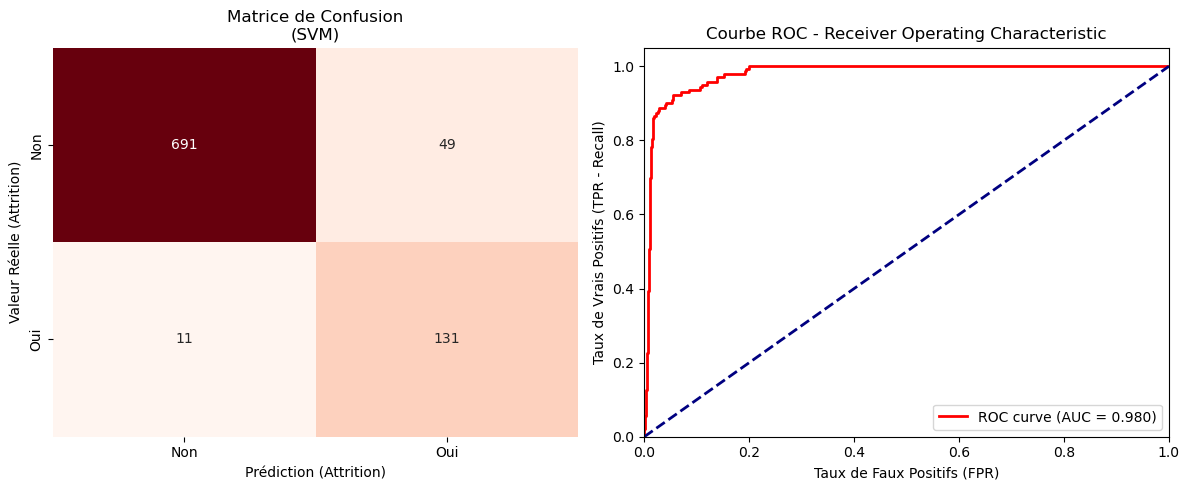

In [ ]:
# Brique 18 - Matrice de Confusion et Courbe ROC / AUC (SVM)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 1. Matrice de Confusion
cm_svm = confusion_matrix(y_valid, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Reds', cbar=False, ax=ax1,
            xticklabels=['Non', 'Oui'], yticklabels=['Non', 'Oui'])
ax1.set_title("Matrice de Confusion\n(SVM)")
ax1.set_xlabel("Prédiction (Attrition)")
ax1.set_ylabel("Valeur Réelle (Attrition)")

# 2. Courbe ROC
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_valid, y_pred_proba_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

ax2.plot(fpr_svm, tpr_svm, color='red', lw=2, label=f'ROC curve (AUC = {roc_auc_svm:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Taux de Faux Positifs (FPR)')
ax2.set_ylabel('Taux de Vrais Positifs (TPR - Recall)')
ax2.set_title("Courbe ROC - Receiver Operating Characteristic")
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [ ]:
# Brique 19 - Visualisation 3D Plotly avec attrition en axe Z (SVM)

if len(available_xy_features) < 2:
    print('\nVisualisation 3D non generee: moins de 2 variables numeriques disponibles pour X et Y.')
else:
    viz_df_svm = X_valid[available_xy_features].copy()
    viz_df_svm['Attrition_Reelle'] = y_valid.values.astype(int)
    viz_df_svm['Prediction_Classe'] = y_pred_svm.astype(int)
    viz_df_svm['Prediction_Proba'] = y_pred_proba_svm

    hover_text_svm = [
        f"Attrition reelle: {int(a)}<br>Prediction classe: {int(pc)}<br>Probabilite (Classe 1): {p:.3f}"
        for a, pc, p in zip(
            viz_df_svm['Attrition_Reelle'],
            viz_df_svm['Prediction_Classe'],
            viz_df_svm['Prediction_Proba']
        )
    ]

    fig_svm = go.Figure(
        data=[
            go.Scatter3d(
                x=viz_df_svm[available_xy_features[0]],
                y=viz_df_svm[available_xy_features[1]],
                z=viz_df_svm['Attrition_Reelle'],
                mode='markers',
                marker=dict(
                    size=5,
                    color=viz_df_svm['Prediction_Classe'],
                    colorscale='Reds',
                    cmin=0,
                    cmax=1,
                    opacity=0.8,
                    colorbar=dict(title='Classe predite (0/1)')
                ),
                text=hover_text_svm,
                hovertemplate='%{text}<extra></extra>'
            )
        ]
    )

    fig_svm.update_layout(
        title='Visualisation 3D (SVM) - Attrition reelle en axe Z',
        scene=dict(
            xaxis_title=available_xy_features[0],
            yaxis_title=available_xy_features[1],
            zaxis_title='Attrition reelle (0/1)',
            zaxis=dict(tickmode='array', tickvals=[0, 1])
        ),
        margin=dict(l=0, r=0, b=0, t=45)
    )

    fig_svm.show()

## 5e. Modèle de Classification : Naive Bayes

**Description** : Classifie via probabilités conditionnelles (supposées indépendantes = "naïf"). Très rapide.

**Quand l'utiliser** : Baseline rapide, bonne performance relative à sa simplicité. Pas de paramétrage complexe.

**Variante Utilisée** :
- `GaussianNB()` : Assume distributions gaussiennes pour features continus

In [ ]:
# Brique 20 - Pipeline et Entraînement Naive Bayes (80/20)

from sklearn.naive_bayes import GaussianNB

# Pipeline: Normalisation -> Gaussian Naive Bayes
# (Bien que Naive Bayes ne nécessite pas strictement une mise à l'échelle, 
# la maintenir permet une comparaison directe sur les mêmes caractéristiques standardisées)
pipeline_nb = Pipeline([
    ('scaler', StandardScaler()),
    ('nb', GaussianNB())
])

print("Entraînement du modèle Naive Bayes Gaussien...")
pipeline_nb.fit(X_train, y_train)

# Prédictions sur la validation
y_pred_proba_nb = pipeline_nb.predict_proba(X_valid)[:, 1] # probabilité de la classe 1
y_pred_nb = pipeline_nb.predict(X_valid)

# Indicateurs de base
acc_nb = accuracy_score(y_valid, y_pred_nb)
prec_nb = precision_score(y_valid, y_pred_nb)
rec_nb = recall_score(y_valid, y_pred_nb)
f1_nb = f1_score(y_valid, y_pred_nb)

print(f"\nPerformances du Naive Bayes sur l'échantillon de validation (N={len(y_valid)}):")
print(f"Accuracy  : {acc_nb:.4f}")
print(f"Précision : {prec_nb:.4f}")
print(f"Rappel    : {rec_nb:.4f}")
print(f"F1-score  : {f1_nb:.4f}")
print("\nRapport de métriques Détaillé:\n", classification_report(y_valid, y_pred_nb))

Entraînement du modèle Naive Bayes Gaussien...

Performances du Naive Bayes sur l'échantillon de validation (N=882):
Accuracy  : 0.8175
Précision : 0.4395
Rappel    : 0.4859
F1-score  : 0.4615

Rapport de métriques Détaillé:
               precision    recall  f1-score   support

         0.0       0.90      0.88      0.89       740
         1.0       0.44      0.49      0.46       142

    accuracy                           0.82       882
   macro avg       0.67      0.68      0.68       882
weighted avg       0.83      0.82      0.82       882



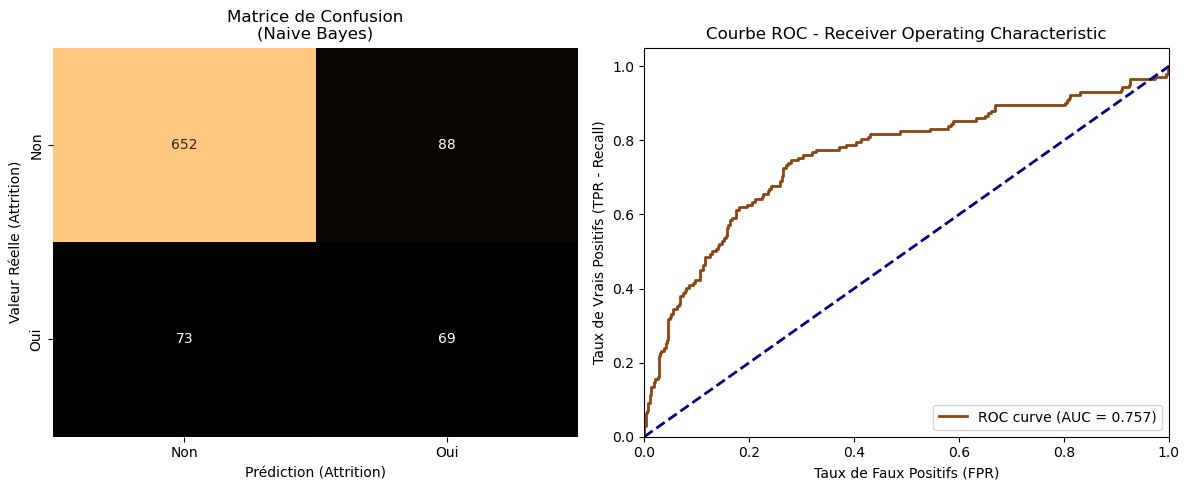

In [ ]:
# Brique 21 - Matrice de Confusion et Courbe ROC / AUC (Naive Bayes)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 1. Matrice de Confusion
cm_nb = confusion_matrix(y_valid, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='copper', cbar=False, ax=ax1,
            xticklabels=['Non', 'Oui'], yticklabels=['Non', 'Oui'])
ax1.set_title("Matrice de Confusion\n(Naive Bayes)")
ax1.set_xlabel("Prédiction (Attrition)")
ax1.set_ylabel("Valeur Réelle (Attrition)")

# 2. Courbe ROC
fpr_nb, tpr_nb, thresholds_nb = roc_curve(y_valid, y_pred_proba_nb)
roc_auc_nb = auc(fpr_nb, tpr_nb)

ax2.plot(fpr_nb, tpr_nb, color='saddlebrown', lw=2, label=f'ROC curve (AUC = {roc_auc_nb:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Taux de Faux Positifs (FPR)')
ax2.set_ylabel('Taux de Vrais Positifs (TPR - Recall)')
ax2.set_title("Courbe ROC - Receiver Operating Characteristic")
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [ ]:
# Brique 22 - Visualisation 3D Plotly avec attrition en axe Z (Naive Bayes)

if len(available_xy_features) < 2:
    print('\nVisualisation 3D non generee: moins de 2 variables numeriques disponibles pour X et Y.')
else:
    viz_df_nb = X_valid[available_xy_features].copy()
    viz_df_nb['Attrition_Reelle'] = y_valid.values.astype(int)
    viz_df_nb['Prediction_Classe'] = y_pred_nb.astype(int)
    viz_df_nb['Prediction_Proba'] = y_pred_proba_nb

    hover_text_nb = [
        f"Attrition reelle: {int(a)}<br>Prediction classe: {int(pc)}<br>Probabilite (Classe 1): {p:.3f}"
        for a, pc, p in zip(
            viz_df_nb['Attrition_Reelle'],
            viz_df_nb['Prediction_Classe'],
            viz_df_nb['Prediction_Proba']
        )
    ]

    fig_nb = go.Figure(
        data=[
            go.Scatter3d(
                x=viz_df_nb[available_xy_features[0]],
                y=viz_df_nb[available_xy_features[1]],
                z=viz_df_nb['Attrition_Reelle'],
                mode='markers',
                marker=dict(
                    size=5,
                    color=viz_df_nb['Prediction_Classe'],
                    colorscale='purp',
                    cmin=0,
                    cmax=1,
                    opacity=0.8,
                    colorbar=dict(title='Classe predite (0/1)')
                ),
                text=hover_text_nb,
                hovertemplate='%{text}<extra></extra>'
            )
        ]
    )

    fig_nb.update_layout(
        title='Visualisation 3D (Naive Bayes) - Attrition reelle en axe Z',
        scene=dict(
            xaxis_title=available_xy_features[0],
            yaxis_title=available_xy_features[1],
            zaxis_title='Attrition reelle (0/1)',
            zaxis=dict(tickmode='array', tickvals=[0, 1])
        ),
        margin=dict(l=0, r=0, b=0, t=45)
    )

    fig_nb.show()

## 5f. Synthèse Intermédiaire : Comparaison des Modèles de Base

Visualisation comparative des performances des modèles simples (LogReg, DT, KNN, SVM, NB) en termes de F1-Score, Recall, Precision sur l'ensemble de validation.

→ Nous verrons lequel est le **champion parmi ces modèles simples** avant de passer aux ensembles.

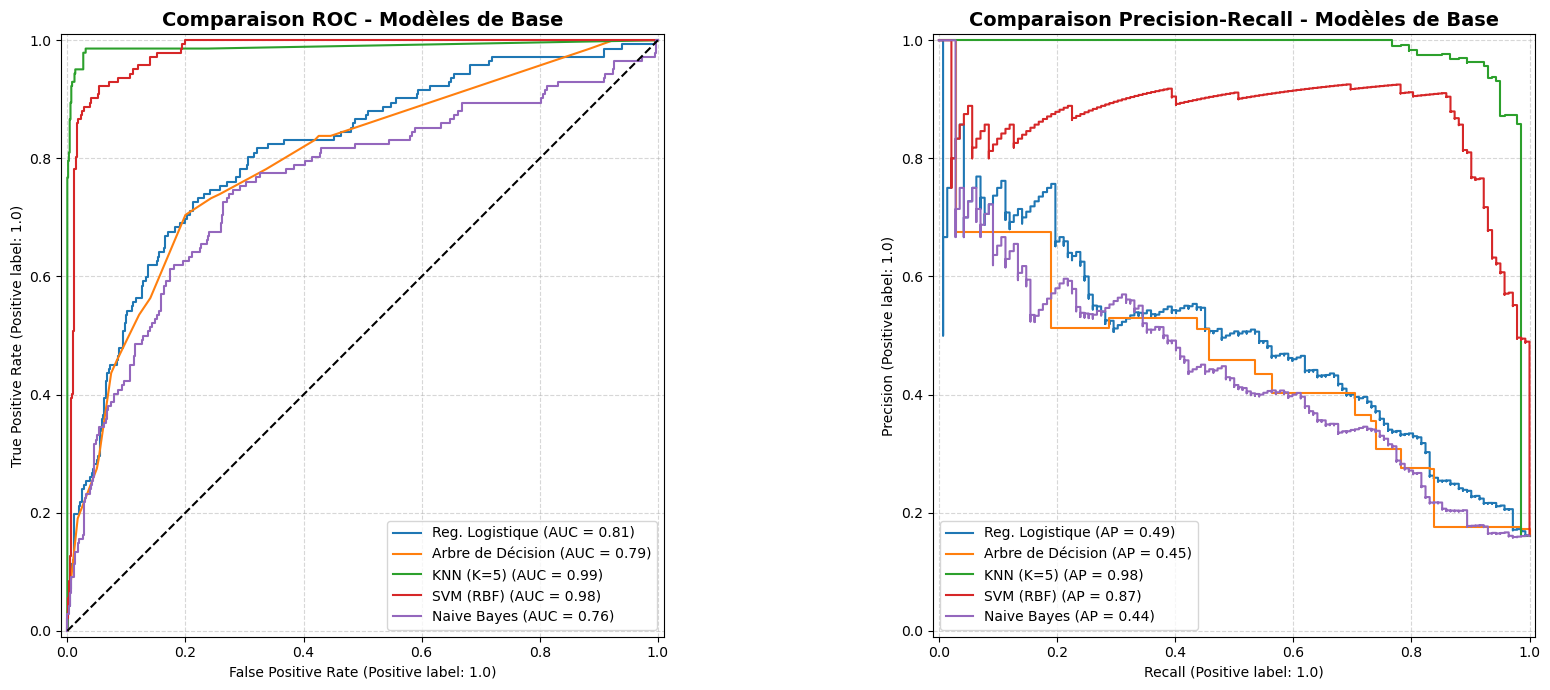


--- Tableau Récapitulatif (Trié par F1-Score) ---


,F1-Score,Recall (Rappel),Precision,Accuracy
Modèle,,,,
KNN (K=5),0.905660,0.845070,0.975610,0.971655
SVM (RBF),0.813665,0.922535,0.727778,0.931973
Arbre de Décision,0.512821,0.704225,0.403226,0.784580
Reg. Logistique,0.504902,0.725352,0.387218,0.770975
Naive Bayes,0.461538,0.485915,0.439490,0.817460


In [ ]:
# Brique 22.5 - Comparaison des Modèles de Base (Simplistes)
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

# Regroupement des modèles de base
basic_pipelines = {
    'Reg. Logistique': pipeline_logreg,
    'Arbre de Décision': pipeline_dt,
    'KNN (K=5)': pipeline_knn,
    'SVM (RBF)': pipeline_svm,
    'Naive Bayes': pipeline_nb
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# 1. Courbes ROC
for name, p in basic_pipelines.items():
    RocCurveDisplay.from_estimator(p, X_valid, y_valid, ax=ax1, name=name)
ax1.set_title("Comparaison ROC - Modèles de Base", fontsize=14, weight='bold')
ax1.plot([0, 1], [0, 1], linestyle='--', color='black') # Ligne de chance
ax1.grid(True, linestyle='--', alpha=0.5)

# 2. Courbes Precision-Recall
for name, p in basic_pipelines.items():
    PrecisionRecallDisplay.from_estimator(p, X_valid, y_valid, ax=ax2, name=name)
ax2.set_title("Comparaison Precision-Recall - Modèles de Base", fontsize=14, weight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Tableau recapitulatif (sur Validation)
recap_data = []
for name, p in basic_pipelines.items():
    y_pred_tmp = p.predict(X_valid)
    recap_data.append({
        'Modèle': name,
        'F1-Score': f1_score(y_valid, y_pred_tmp),
        'Recall (Rappel)': recall_score(y_valid, y_pred_tmp),
        'Precision': precision_score(y_valid, y_pred_tmp),
        'Accuracy': accuracy_score(y_valid, y_pred_tmp)
    })

df_recap_basic = pd.DataFrame(recap_data).sort_values(by='F1-Score', ascending=False).set_index('Modèle')
print("\n--- Tableau Récapitulatif (Trié par F1-Score) ---")
display(df_recap_basic)

In [ ]:
# Brique 22.7 - Heatmap des Performances : Comparaison Visuelle Avancée

print("\n" + "="*70)
print("COMPARAISON AVANCÉE : Heatmap des Performances")
print("="*70)

# Créer une heatmap avec toutes les métriques
df_heatmap = df_recap_basic.copy()

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(df_heatmap.T.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

# Configuration des axes
ax.set_xticks(range(len(df_heatmap)))
ax.set_yticks(range(len(df_heatmap.columns)))
ax.set_xticklabels(df_heatmap.index, rotation=45, ha='right')
ax.set_yticklabels(df_heatmap.columns)

# Ajouter les valeurs numériques dans chaque cellule
for i in range(len(df_heatmap.columns)):
    for j in range(len(df_heatmap)):
        value = df_heatmap.T.values[i, j]
        text_color = 'white' if value < 0.5 else 'black'
        ax.text(j, i, f'{value:.3f}', ha='center', va='center', 
                color=text_color, fontweight='bold', fontsize=11)

ax.set_title('Heatmap des Performances - Modèles de Base', fontsize=14, weight='bold', pad=20)
plt.colorbar(im, ax=ax, label='Score (0 à 1)')
plt.tight_layout()
plt.show()

print("\n✅ Heatmap générée. Les valeurs proches de 1 (vert) indiquent une meilleure performance.")

In [ ]:
# Brique 22.8 - Graphique Radar (Spider Chart) : Vue Multidimensionnelle

print("\n" + "="*70)
print("COMPARAISON AVANCÉE : Graphique Radar (Spider Chart)")
print("="*70)

# Créer un graphique radar avec Plotly
categories = df_recap_basic.columns.tolist()

fig_radar = go.Figure()

for model_name in df_recap_basic.index:
    values = df_recap_basic.loc[model_name].values.tolist()
    values += values[:1]  # Fermer le polygone
    
    fig_radar.add_trace(go.Scatterpolar(
        r=values,
        theta=categories + [categories[0]],
        fill='toself',
        name=model_name,
        line=dict(width=2)
    ))

fig_radar.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1],
            tickfont=dict(size=10)
        ),
        angularaxis=dict(tickfont=dict(size=11))
    ),
    title='<b>Comparaison Radar</b> - Toutes les Métriques des Modèles de Base',
    showlegend=True,
    width=900,
    height=700
)

fig_radar.show()

print("\n✅ Graphique radar généré. Chaque axe représente une métrique, chaque polygone un modèle.")

In [ ]:
# Brique 22.6 - Graphique Comparatif Visuel des Modèles Simplistes
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# On inverse l'ordre pour que le meilleur soit en haut sur le graphique (barh)
df_plot = df_recap_basic.sort_values(by='F1-Score', ascending=True)

# Pour afficher F1-Score et Recall sur un même graphique en barres groupées
df_plot[['F1-Score', 'Recall (Rappel)']].plot(kind='barh', ax=ax, color=['#FF9999', '#66B2FF'])

ax.set_title("Comparaison Visuelle - Modèles Simplistes (Validation)", fontsize=14, weight='bold')
ax.set_xlabel("Score (0 à 1)")
ax.set_ylabel("Modèle")
ax.set_xlim(0, 1.05)

# Ajout des valeurs numériques au bout des barres
for i, (idx, row) in enumerate(df_plot.iterrows()):
    ax.text(row['F1-Score'] + 0.01, i - 0.15, f"{row['F1-Score']:.3f}", va='center', color='black', fontsize=10)
    ax.text(row['Recall (Rappel)'] + 0.01, i + 0.15, f"{row['Recall (Rappel)']:.3f}", va='center', color='black', fontsize=10)

plt.tight_layout()
plt.show()

## 5g. Modèles Ensemblistes (La force du nombre)

Les modèles ensemblistes combinent plusieurs modèles simples pour réduire l'overfitting et améliorer la robustesse.

### Random Forest
**Paramètres** :
- `n_estimators=100` : Nombre d'arbres (plus = plus robuste, mais gain décroissant)

- `max_depth=None` : Pas de limite (chaque arbre peut être profond)**Logique** : Chaque nouvel arbre corrige les erreurs du précédent = apprentissage progressif

- `class_weight='balanced'` : Équilibre les classes

- `max_depth=5` : Profondeur (petit pour arbres faibles)

**Logique** : Bootstrap (réechantillonnage) + Chaque arbre sur subset → Vote majoritaire- `learning_rate=0.1` : Taux d'apprentissage (petit = convergence lente mais stable)

- `n_estimators=100` : Nombre d'arbres séquentiels

### Gradient Boosting**Paramètres** :

In [ ]:
# Brique 23 - A. Le Bagging : Random Forest (Entraînement)
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
])

print("Entraînement du modèle Random Forest avec class_weight='balanced'...")
pipeline_rf.fit(X_train, y_train)

# Prédictions sur la validation
y_pred_proba_rf = pipeline_rf.predict_proba(X_valid)[:, 1] # probabilité de la classe 1
y_pred_rf = pipeline_rf.predict(X_valid)

# Indicateurs de base
acc_rf = accuracy_score(y_valid, y_pred_rf)
prec_rf = precision_score(y_valid, y_pred_rf)
rec_rf = recall_score(y_valid, y_pred_rf)
f1_rf = f1_score(y_valid, y_pred_rf)
pr_auc_rf = average_precision_score(y_valid, y_pred_proba_rf)

print(f"\nPerformances de Random Forest sur l'échantillon de validation (N={len(y_valid)}):")
print(f"Accuracy  : {acc_rf:.4f}")
print(f"Précision : {prec_rf:.4f}")
print(f"Rappel    : {rec_rf:.4f}")
print(f"F1-score  : {f1_rf:.4f}")
print(f"PR AUC    : {pr_auc_rf:.4f}")
print("\nRapport de métriques Détaillé:\n", classification_report(y_valid, y_pred_rf))

Entraînement du modèle Random Forest avec class_weight='balanced'...

Performances de Random Forest sur l'échantillon de validation (N=882):
Accuracy  : 0.9921
Précision : 1.0000
Rappel    : 0.9507
F1-score  : 0.9747
PR AUC    : 0.9922

Rapport de métriques Détaillé:
               precision    recall  f1-score   support

         0.0       0.99      1.00      1.00       740
         1.0       1.00      0.95      0.97       142

    accuracy                           0.99       882
   macro avg       1.00      0.98      0.99       882
weighted avg       0.99      0.99      0.99       882



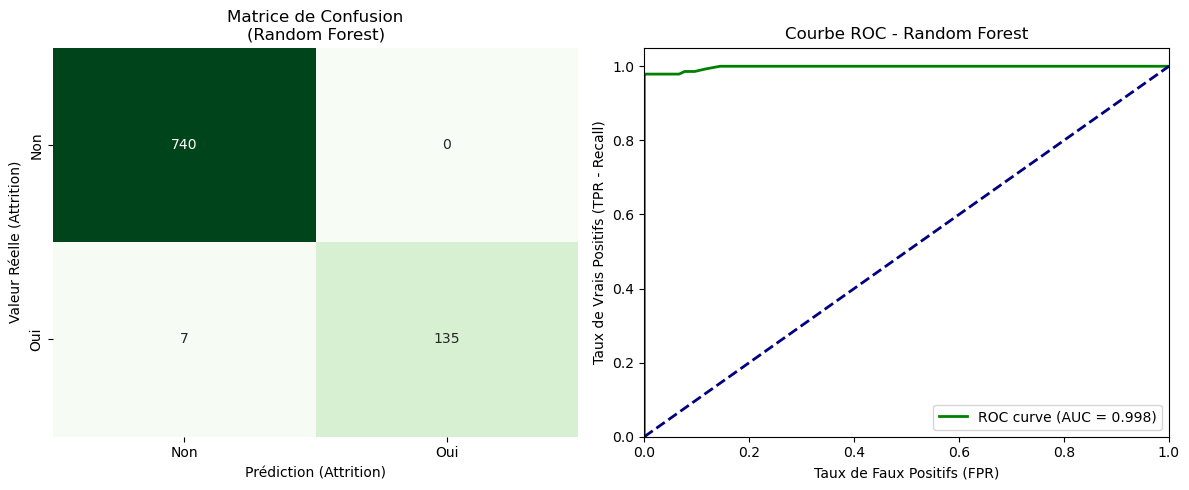

In [ ]:
# Brique 24 - Matrice de Confusion et Courbe ROC / AUC (Random Forest)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 1. Matrice de Confusion
cm_rf = confusion_matrix(y_valid, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', cbar=False, ax=ax1,
            xticklabels=['Non', 'Oui'], yticklabels=['Non', 'Oui'])
ax1.set_title("Matrice de Confusion\n(Random Forest)")
ax1.set_xlabel("Prédiction (Attrition)")
ax1.set_ylabel("Valeur Réelle (Attrition)")

# 2. Courbe ROC
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_valid, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

ax2.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'ROC curve (AUC = {roc_auc_rf:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Taux de Faux Positifs (FPR)')
ax2.set_ylabel('Taux de Vrais Positifs (TPR - Recall)')
ax2.set_title("Courbe ROC - Random Forest")
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [ ]:
# Brique 25 - Visualisation 3D Plotly avec attrition en axe Z (Random Forest)

if len(available_xy_features) < 2:
    print('\nVisualisation 3D non generee: moins de 2 variables numeriques...')
else:
    viz_df_rf = X_valid[available_xy_features].copy()
    viz_df_rf['Attrition_Reelle'] = y_valid.values.astype(int)
    viz_df_rf['Prediction_Classe'] = y_pred_rf.astype(int)
    viz_df_rf['Prediction_Proba'] = y_pred_proba_rf

    hover_text_rf = [f"Attrition reelle: {int(a)}<br>Prediction classe: {int(pc)}<br>Probabilite: {p:.3f}" 
                     for a, pc, p in zip(viz_df_rf['Attrition_Reelle'], viz_df_rf['Prediction_Classe'], viz_df_rf['Prediction_Proba'])]

    fig_rf = go.Figure(data=[go.Scatter3d(
        x=viz_df_rf[available_xy_features[0]], y=viz_df_rf[available_xy_features[1]], z=viz_df_rf['Attrition_Reelle'], mode='markers',
        marker=dict(size=5, color=viz_df_rf['Prediction_Classe'], colorscale='Greens', cmin=0, cmax=1, opacity=0.8, colorbar=dict(title='Classe predite')),
        text=hover_text_rf, hovertemplate='%{text}<extra></extra>'
    )])

    fig_rf.update_layout(title='Visualisation 3D (Random Forest) - Attrition reelle en axe Z',
                         scene=dict(xaxis_title=available_xy_features[0], yaxis_title=available_xy_features[1], zaxis_title='Attrition reelle', zaxis=dict(tickmode='array', tickvals=[0, 1])),
                         margin=dict(l=0, r=0, b=0, t=45))
    fig_rf.show()

In [ ]:
# Brique 26 - B. Le Boosting : Gradient Boosting (Entraînement)
# Le GradientBoostingClassifier n'accepte pas directement 'class_weight'. On peut utiliser un SMOTE dans le pipeline (via imblearn) si besoin,
# mais ici nous optimisons déjà via l'ensemble. 
from sklearn.ensemble import GradientBoostingClassifier

pipeline_gb = Pipeline([
    ('scaler', StandardScaler()),
    ('gb', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42))
])

print("Entraînement du modèle Gradient Boosting...")
pipeline_gb.fit(X_train, y_train)

# Prédictions sur la validation
y_pred_proba_gb = pipeline_gb.predict_proba(X_valid)[:, 1] # probabilité de la classe 1
y_pred_gb = pipeline_gb.predict(X_valid)

# Indicateurs de base
acc_gb = accuracy_score(y_valid, y_pred_gb)
prec_gb = precision_score(y_valid, y_pred_gb)
rec_gb = recall_score(y_valid, y_pred_gb)
f1_gb = f1_score(y_valid, y_pred_gb)
pr_auc_gb = average_precision_score(y_valid, y_pred_proba_gb)

print(f"\nPerformances de Gradient Boosting sur l'échantillon validation (N={len(y_valid)}):")
print(f"Accuracy  : {acc_gb:.4f}")
print(f"Précision : {prec_gb:.4f}")
print(f"Rappel    : {rec_gb:.4f}")
print(f"F1-score  : {f1_gb:.4f}")
print(f"PR AUC    : {pr_auc_gb:.4f}")
print("\nRapport de métriques Détaillé:\n", classification_report(y_valid, y_pred_gb))

Entraînement du modèle Gradient Boosting...

Performances de Gradient Boosting sur l'échantillon validation (N=882):
Accuracy  : 0.8968
Précision : 0.8923
Rappel    : 0.4085
F1-score  : 0.5604
PR AUC    : 0.7602

Rapport de métriques Détaillé:
               precision    recall  f1-score   support

         0.0       0.90      0.99      0.94       740
         1.0       0.89      0.41      0.56       142

    accuracy                           0.90       882
   macro avg       0.89      0.70      0.75       882
weighted avg       0.90      0.90      0.88       882



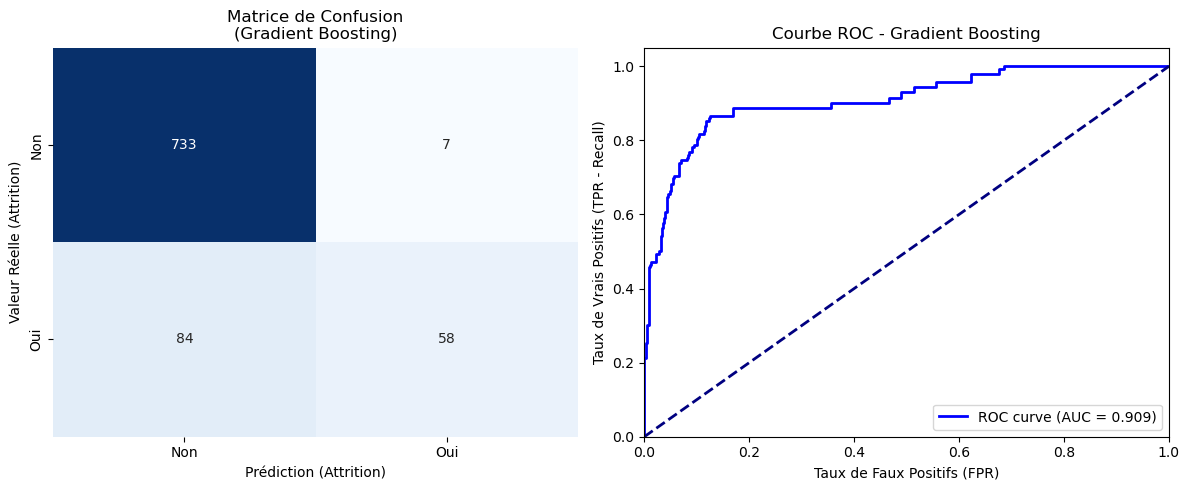

In [ ]:
# Brique 27 - Matrice de Confusion et Courbe ROC / AUC (Gradient Boosting)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 1. Matrice de Confusion
cm_gb = confusion_matrix(y_valid, y_pred_gb)
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1,
            xticklabels=['Non', 'Oui'], yticklabels=['Non', 'Oui'])
ax1.set_title("Matrice de Confusion\n(Gradient Boosting)")
ax1.set_xlabel("Prédiction (Attrition)")
ax1.set_ylabel("Valeur Réelle (Attrition)")

# 2. Courbe ROC
fpr_gb, tpr_gb, thresholds_gb = roc_curve(y_valid, y_pred_proba_gb)
roc_auc_gb = auc(fpr_gb, tpr_gb)

ax2.plot(fpr_gb, tpr_gb, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc_gb:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Taux de Faux Positifs (FPR)')
ax2.set_ylabel('Taux de Vrais Positifs (TPR - Recall)')
ax2.set_title("Courbe ROC - Gradient Boosting")
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [ ]:
# Brique 28 - Visualisation 3D Plotly avec attrition en axe Z (Gradient Boosting)

if len(available_xy_features) < 2:
    print('\nVisualisation 3D non generee: moins de 2 variables numeriques...')
else:
    viz_df_gb = X_valid[available_xy_features].copy()
    viz_df_gb['Attrition_Reelle'] = y_valid.values.astype(int)
    viz_df_gb['Prediction_Classe'] = y_pred_gb.astype(int)
    viz_df_gb['Prediction_Proba'] = y_pred_proba_gb

    hover_text_gb = [f"Attrition reelle: {int(a)}<br>Prediction classe: {int(pc)}<br>Probabilite: {p:.3f}" 
                     for a, pc, p in zip(viz_df_gb['Attrition_Reelle'], viz_df_gb['Prediction_Classe'], viz_df_gb['Prediction_Proba'])]

    fig_gb = go.Figure(data=[go.Scatter3d(
        x=viz_df_gb[available_xy_features[0]], y=viz_df_gb[available_xy_features[1]], z=viz_df_gb['Attrition_Reelle'], mode='markers',
        marker=dict(size=5, color=viz_df_gb['Prediction_Classe'], colorscale='Blues', cmin=0, cmax=1, opacity=0.8, colorbar=dict(title='Classe predite')),
        text=hover_text_gb, hovertemplate='%{text}<extra></extra>'
    )])

    fig_gb.update_layout(title='Visualisation 3D (Gradient Boosting) - Attrition reelle en axe Z',
                         scene=dict(xaxis_title=available_xy_features[0], yaxis_title=available_xy_features[1], zaxis_title='Attrition reelle', zaxis=dict(tickmode='array', tickvals=[0, 1])),
                         margin=dict(l=0, r=0, b=0, t=45))
    fig_gb.show()

In [ ]:
# Brique 29 - C. Le Stacking : Méta-Modèle (Entraînement)
from sklearn.ensemble import StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# On choisit nos meilleurs modèles pour former une équipe : Random Forest, SVM robuste et K-Nearest Neighbors
base_learners = [
    ('rf', RandomForestClassifier(n_estimators=50, class_weight='balanced', random_state=42)),
    ('svm', SVC(probability=True, class_weight='balanced', random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5, weights='distance'))
]

pipeline_stack = Pipeline([
    ('scaler', StandardScaler()),
    ('stack', StackingClassifier(
        estimators=base_learners,
        final_estimator=LogisticRegression(class_weight='balanced'),
        cv=5 # <- Important: Définit une validation croisée interne explicite (out-of-fold) pour éviter le surapprentissage du méta-modèle.
    ))
])

print("Entraînement du modèle de Stacking...")
pipeline_stack.fit(X_train, y_train)

# Prédictions sur la validation
y_pred_proba_stack = pipeline_stack.predict_proba(X_valid)[:, 1] # probabilité de la classe 1
y_pred_stack = pipeline_stack.predict(X_valid)

# Indicateurs de base
acc_stack = accuracy_score(y_valid, y_pred_stack)
prec_stack = precision_score(y_valid, y_pred_stack)
rec_stack = recall_score(y_valid, y_pred_stack)
f1_stack = f1_score(y_valid, y_pred_stack)
# PR-AUC pour une classe déséquilibrée
from sklearn.metrics import average_precision_score
pr_auc_stack = average_precision_score(y_valid, y_pred_proba_stack)

print(f"\nPerformances du Stacking sur l'échantillon de validation (N={len(y_valid)}):")
print(f"Accuracy  : {acc_stack:.4f}")
print(f"Précision : {prec_stack:.4f}")
print(f"Rappel    : {rec_stack:.4f}")
print(f"F1-score  : {f1_stack:.4f}")
print(f"PR AUC    : {pr_auc_stack:.4f}")
print("\nRapport de métriques Détaillé:\n", classification_report(y_valid, y_pred_stack))

Entraînement du modèle de Stacking...

Performances du Stacking sur l'échantillon de validation (N=882):
Accuracy  : 0.9875
Précision : 0.9456
Rappel    : 0.9789
F1-score  : 0.9619
PR AUC    : 0.9930

Rapport de métriques Détaillé:
               precision    recall  f1-score   support

         0.0       1.00      0.99      0.99       740
         1.0       0.95      0.98      0.96       142

    accuracy                           0.99       882
   macro avg       0.97      0.98      0.98       882
weighted avg       0.99      0.99      0.99       882



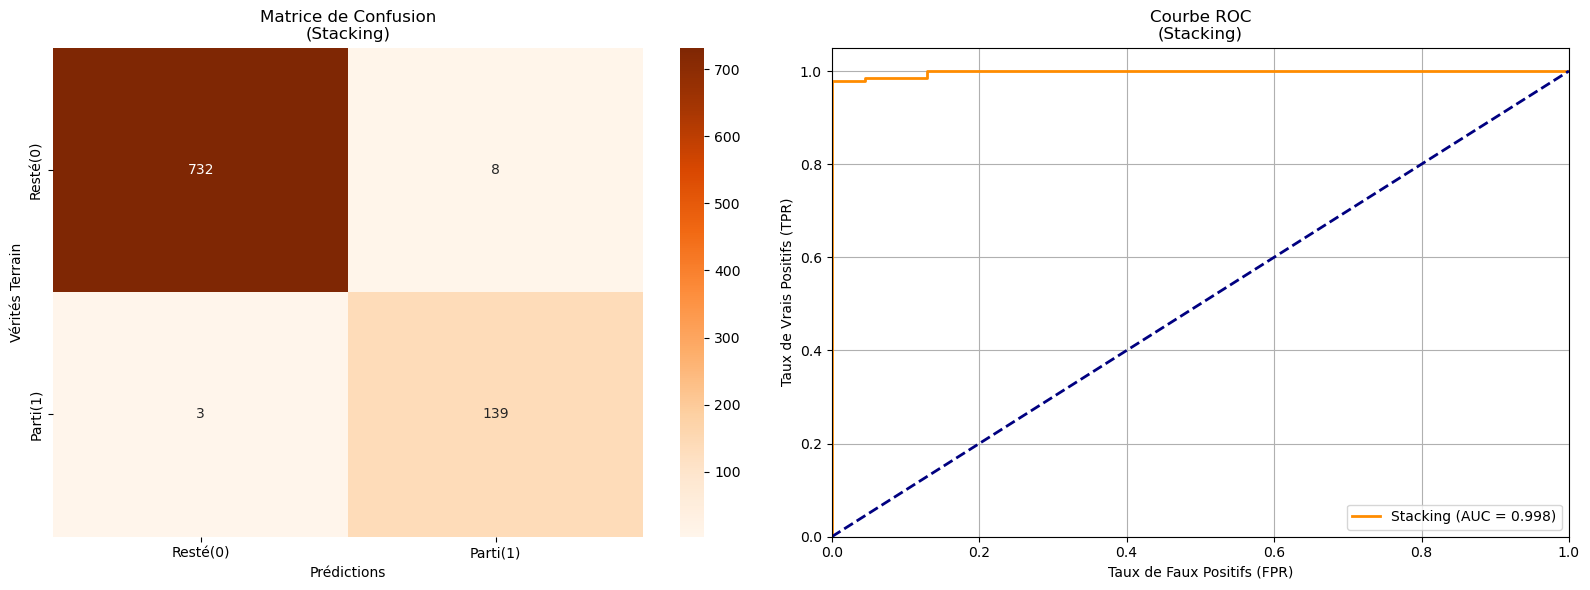

In [ ]:
# Brique 30 - C. Le Stacking : Matrice de Confusion & AUC ROC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

cm_stack = confusion_matrix(y_valid, y_pred_stack)
sns.heatmap(cm_stack, annot=True, fmt='d', cmap='Oranges', ax=ax[0])
ax[0].set_title('Matrice de Confusion\n(Stacking)')
ax[0].set_xlabel('Prédictions')
ax[0].set_ylabel('Vérités Terrain')
ax[0].xaxis.set_ticklabels(['Resté(0)', 'Parti(1)'])
ax[0].yaxis.set_ticklabels(['Resté(0)', 'Parti(1)'])

# Calcul courbe et aire sous la courbe
fpr_stack, tpr_stack, _ = roc_curve(y_valid, y_pred_proba_stack)
roc_auc_stack = auc(fpr_stack, tpr_stack)

ax[1].plot(fpr_stack, tpr_stack, color='darkorange', lw=2, label=f'Stacking (AUC = {roc_auc_stack:.3f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('Taux de Faux Positifs (FPR)')
ax[1].set_ylabel('Taux de Vrais Positifs (TPR)')
ax[1].set_title('Courbe ROC\n(Stacking)')
ax[1].legend(loc="lower right")
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Brique 31 - C. Le Stacking : Visualisation Plotly 3D Interactive
import plotly.graph_objects as go
from sklearn.decomposition import PCA

print("Compression 3D...")
pca_3d = PCA(n_components=3)
X_valid_3d = pca_3d.fit_transform(X_valid)

df_vis_stack = pd.DataFrame(X_valid_3d, columns=['PC1', 'PC2', 'PC3'])
df_vis_stack['Actual'] = y_valid.values
df_vis_stack['Predicted'] = y_pred_stack

color_discrete_map = {
    (0, 0): 'blue',    # True Negatives (Correctly staying)
    (1, 1): 'red',     # True Positives (Correctly leaving)
    (0, 1): 'orange',  # False Positives (Incorrectly predicted to leave)
    (1, 0): 'purple'   # False Negatives (Incorrectly predicted to stay)
}

df_vis_stack['Status'] = df_vis_stack.apply(lambda row: 'TN' if row['Actual'] == 0 and row['Predicted'] == 0 else
                                   ('TP' if row['Actual'] == 1 and row['Predicted'] == 1 else
                                   ('FP' if row['Actual'] == 0 and row['Predicted'] == 1 else 'FN')), axis=1)

colors = df_vis_stack[['Actual', 'Predicted']].apply(lambda x: color_discrete_map[(x[0], x[1])], axis=1)

fig_scat_stack = go.Figure(data=[go.Scatter3d(
    x=df_vis_stack['PC1'],
    y=df_vis_stack['PC2'],
    z=df_vis_stack['PC3'],
    mode='markers',
    marker=dict(
        size=5,
        color=colors,
        opacity=0.8
    ),
    text=df_vis_stack['Status']
)])

fig_scat_stack.update_layout(
    title=f"Stacking : {acc_stack*100:.1f}% Acc (Bleu=Vrai Négatif, Rouge=Vrai Positif)",
    scene=dict(xaxis_title='Composant Principal 1',
               yaxis_title='Composant Principal 2',
               zaxis_title='Proba (Représentée en 3D)')
)
fig_scat_stack.show()

Compression 3D...


/tmp/ipykernel_3018/2035400058.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  colors = df_vis_stack[['Actual', 'Predicted']].apply(lambda x: color_discrete_map[(x[0], x[1])], axis=1)


### XGBoost : Le Modèle Optimisé

XGBoost est l'implémentation optimisée et accélérée du Gradient Boosting, avec régularisation intégrée pour éviter les fuites.

In [ ]:
!pip install xgboost shap

import xgboost as xgb

pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, class_weight='balanced'))
])

print("Entraînement du modèle XGBoost...")
pipeline_xgb.fit(X_train, y_train)

# Prédictions sur la validation
y_pred_proba_xgb = pipeline_xgb.predict_proba(X_valid)[:, 1] # probabilité de la classe 1
y_pred_xgb = pipeline_xgb.predict(X_valid)

# Indicateurs de base
acc_xgb = accuracy_score(y_valid, y_pred_xgb)
prec_xgb = precision_score(y_valid, y_pred_xgb)
rec_xgb = recall_score(y_valid, y_pred_xgb)
f1_xgb = f1_score(y_valid, y_pred_xgb)

print(f"\nPerformances de XGBoost sur validation (N={len(y_valid)}):")
print(f"Accuracy  : {acc_xgb:.4f}")
print(f"Précision : {prec_xgb:.4f}")
print(f"Rappel    : {rec_xgb:.4f}")
print(f"F1-score  : {f1_xgb:.4f}")
print("\nRapport:\n", classification_report(y_valid, y_pred_xgb))


Entraînement du modèle XGBoost...


/home/alban/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [13:48:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Performances de XGBoost sur validation (N=882):
Accuracy  : 0.9966
Précision : 1.0000
Rappel    : 0.9789
F1-score  : 0.9893

Rapport:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       740
         1.0       1.00      0.98      0.99       142

    accuracy                           1.00       882
   macro avg       1.00      0.99      0.99       882
weighted avg       1.00      1.00      1.00       882



## 5h. Comparaison Systématique des Modèles (Validation Croisée et PR-AUC)

Évaluation exhaustive avec **StratifiedKFold 5-fold** pour tous les modèles, avec tableaux de comparaison train/test pour détecter l'overfitting, et courbes Precision-Recall.

In [ ]:
# Brique 32 - Validation Croisée Stratifiée Interactive
from sklearn.model_selection import StratifiedKFold, cross_validate
import time

pipelines_to_compare = {
    'Régression Logistique': pipeline_logreg,
    'Random Forest': pipeline_rf,
    'Gradient Boosting': pipeline_gb,
    'SVM': pipeline_svm,
    'XGBoost': pipeline_xgb,
    'Stacking': pipeline_stack
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring_metrics = {
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision'
}

cv_results_dict = {}

print("Évaluation en cours via StratifiedKFold (N=5) - sans data leakage...")
start_overall = time.time()

for name, p_line in pipelines_to_compare.items():
    print(f"-> Cross-Validation pour {name}...")
    cv_res = cross_validate(p_line, X_train, y_train, cv=skf, scoring=scoring_metrics, n_jobs=-1)
    
    cv_results_dict[name] = {
        'Recall (Moyen)': cv_res['test_recall'].mean(),
        'F1-Score (Moyen)': cv_res['test_f1'].mean(),
        'ROC-AUC (Moyen)': cv_res['test_roc_auc'].mean(),
        'PR-AUC (Moyen)': cv_res['test_pr_auc'].mean()
    }

end_overall = time.time()
print(f"\nTerminé ! (Temps total : {end_overall - start_overall:.2f} secondes)")

df_cv_results = pd.DataFrame(cv_results_dict).T
print("\n--- Synthèse des Résultats (Validation Croisée) ---")
display(df_cv_results)

Évaluation en cours via StratifiedKFold (N=5) - sans data leakage...
-> Cross-Validation pour Régression Logistique...
-> Cross-Validation pour Random Forest...
-> Cross-Validation pour Gradient Boosting...
-> Cross-Validation pour SVM...
-> Cross-Validation pour XGBoost...


/home/alban/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [13:48:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/alban/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [13:48:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/alban/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [13:48:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/alban/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [13:48:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight", "use_label_encoder" } are not use

-> Cross-Validation pour Stacking...

Terminé ! (Temps total : 36.55 secondes)

--- Synthèse des Résultats (Validation Croisée) ---


,Recall (Moyen),F1-Score (Moyen),ROC-AUC (Moyen),PR-AUC (Moyen)
Régression Logistique,0.764555,0.489381,0.808865,0.480228
Random Forest,0.859401,0.919852,0.989280,0.968061
Gradient Boosting,0.456948,0.590116,0.904119,0.747885
SVM,0.873498,0.794005,0.955686,0.853341
XGBoost,0.890964,0.926441,0.974737,0.945397
Stacking,0.908601,0.891409,0.984743,0.962263


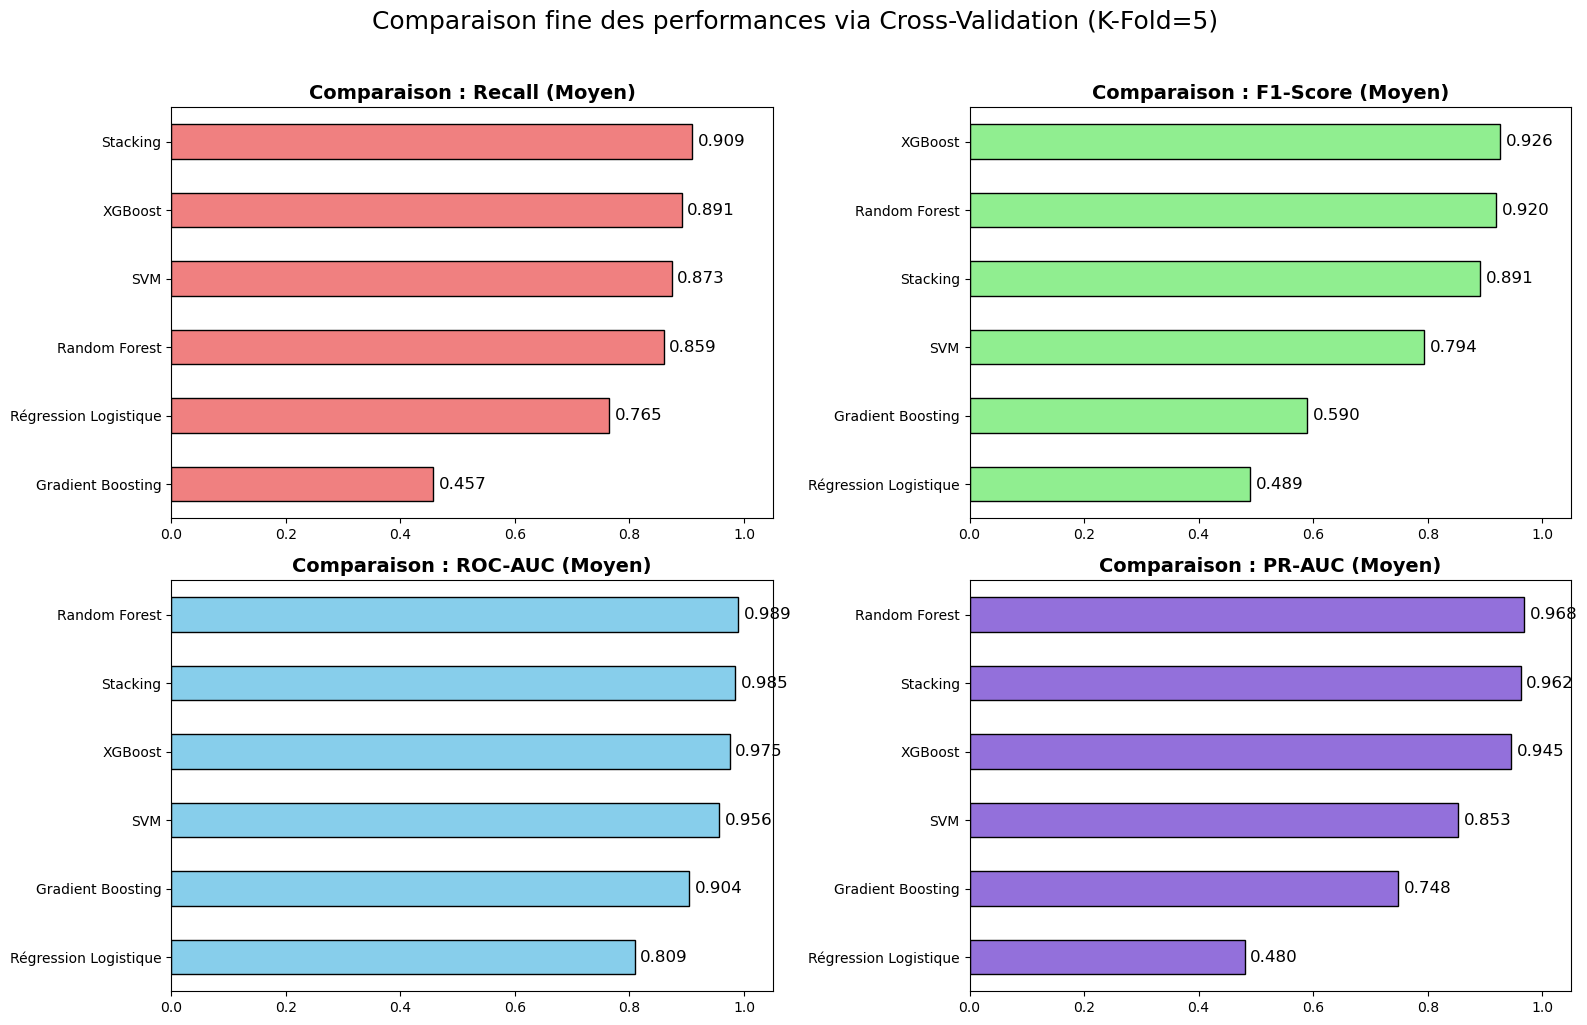

In [ ]:
# Brique 33 - Comparaison visuelle des métriques de CV

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metrics_to_plot = ['Recall (Moyen)', 'F1-Score (Moyen)', 'ROC-AUC (Moyen)', 'PR-AUC (Moyen)']
colors = ['lightcoral', 'lightgreen', 'skyblue', 'mediumpurple']

# Graphiques en barres horizontales pour une meilleure lisibilité
for i, metric in enumerate(metrics_to_plot):
    ax = axes[i//2, i%2]
    # Tri par la valeur de la métrique en cours
    data_sorted = df_cv_results[metric].sort_values()
    data_sorted.plot(kind='barh', ax=ax, color=colors[i], edgecolor='black')
    
    ax.set_title(f'Comparaison : {metric}', fontsize=14, weight='bold')
    ax.set_xlim(0, 1.05)
    
    # Affichage des valeurs exactes à la fin des barres
    for index, value in enumerate(data_sorted):
        ax.text(value + 0.01, index, f'{value:.3f}', va='center', fontsize=12)

plt.suptitle("Comparaison fine des performances via Cross-Validation (K-Fold=5)", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

### Courbe Precision-Recall (Graphe de Décision Final)

La courbe Precision-Recall montre le trade-off entre capturer les départs (Recall) et minimiser les fausses alarmes (Precision). Zone sous la courbe (PR-AUC) = métrique synthétique.

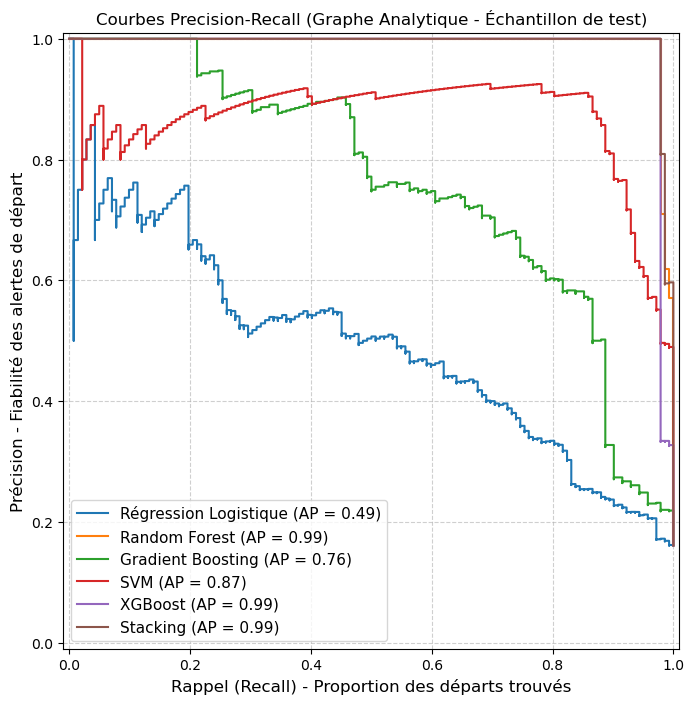

In [ ]:
# Brique 34 - Courbes Precision-Recall comparatives
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(10, 8))

for name, p_line in pipelines_to_compare.items():
    # Ici on observe les prédictions finales sur le set de test/validation non touché
    PrecisionRecallDisplay.from_estimator(p_line, X_valid, y_valid, ax=ax, name=name)

ax.set_title("Courbes Precision-Recall (Graphe Analytique - Échantillon de test)")
plt.legend(loc="lower left", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel("Rappel (Recall) - Proportion des départs trouvés", fontsize=12)
plt.ylabel("Précision - Fiabilité des alertes de départ", fontsize=12)
plt.show()

In [ ]:
# Visualisation 3D Améliorée #1 : Comparaison des Prédictions des Modèles en 3D
# Affiche les données réelles vs prédictions de chaque modèle dans le même espace 3D

print("="*70)
print("VISUALISATION 3D : Comparaison des Prédictions par Modèle")
print("="*70)

# Sélectionner les 3 variables numériques les plus importantes
top_3_features = corr_with_target.abs().nlargest(4)[1:4].index.tolist()
if len(top_3_features) < 3:
    numeric_cols = X_valid.select_dtypes(include=['float64', 'int64']).columns[:3].tolist()
    top_3_features = numeric_cols

print(f"\n🎯 Axes 3D Sélectionnés :")
for i, feature in enumerate(top_3_features, 1):
    print(f"   {i}. {feature:30s} (corrélation: {corr_with_target.get(feature, 0):.3f})")

# Préparer le DataFrame pour la visualisation
viz_3d_df = X_valid[top_3_features].copy()
viz_3d_df['Attrition_Reelle'] = y_valid.values.astype(int)
viz_3d_df['Attrition_Label'] = viz_3d_df['Attrition_Reelle'].map({0: 'Rétention', 1: 'Départ'})

# Ajouter les prédictions de chaque modèle simple
print(f"\n🤖 Génération des prédictions pour chaque modèle...")

models_for_viz = {
    'Reg. Logistique': pipeline_logreg,
    'Arbre Décision': pipeline_dt,
    'KNN': pipeline_knn,
    'SVM': pipeline_svm,
    'Naive Bayes': pipeline_nb,
    'Random Forest': pipeline_rf
}

predictions_viz = {}
for model_name, model_pipe in models_for_viz.items():
    preds = model_pipe.predict(X_valid)
    predictions_viz[model_name] = preds
    viz_3d_df[f'Pred_{model_name}'] = preds

print(f"✅ {len(models_for_viz)} modèles préparés")

# Créer la figure Plotly 3D
fig_3d_models = go.Figure()

# 1. Ajouter les données RÉELLES en premier (trace de référence, semi-transparente)
# Séparées par attrition réelle
for attrition_label, color in [('Rétention', 'lightgreen'), ('Départ', 'lightcoral')]:
    mask = viz_3d_df['Attrition_Label'] == attrition_label
    fig_3d_models.add_trace(go.Scatter3d(
        x=viz_3d_df[mask][top_3_features[0]],
        y=viz_3d_df[mask][top_3_features[1]],
        z=viz_3d_df[mask][top_3_features[2]],
        mode='markers',
        marker=dict(
            size=5,
            color=color,
            opacity=0.4,  # Semi-transparent (référence)
            line=dict(width=0.5, color='gray')
        ),
        text=attrition_label,
        hovertemplate=f'<b>Réel (Données):</b> {attrition_label}<extra></extra>',
        name=f'Réel: {attrition_label}',
        legendgroup='real'
    ))

# 2. Ajouter les prédictions de chaque modèle (traces colorées distinctes)
colors_models = {
    'Reg. Logistique': 'red',
    'Arbre Décision': 'orange',
    'KNN': 'blue',
    'SVM': 'purple',
    'Naive Bayes': 'brown',
    'Random Forest': 'green'
}

for model_name, color in colors_models.items():
    pred_col = f'Pred_{model_name}'
    
    # Pour les prédictions : 1 = Départ (points hauts), 0 = Rétention (points bas)
    fig_3d_models.add_trace(go.Scatter3d(
        x=viz_3d_df[top_3_features[0]],
        y=viz_3d_df[top_3_features[1]],
        z=viz_3d_df[pred_col] * 100,  # Multiplier par 100 pour visualiser en Z
        mode='markers',
        marker=dict(
            size=4,
            color=color,
            opacity=0.6,
            symbol='diamond'  # Symbole différent pour les prédictions
        ),
        text=[f'<b>{model_name}</b><br>Prédiction: {"Départ" if p==1 else "Rétention"}' 
              for p in viz_3d_df[pred_col]],
        hovertemplate='%{text}<extra></extra>',
        name=f'Préd: {model_name}',
        legendgroup='predictions'
    ))

fig_3d_models.update_layout(
    title=f'<b>Comparaison 3D des Prédictions</b><br><sub>Axes: {top_3_features[0]} | {top_3_features[1]} | {top_3_features[2]} (ou Prédiction Modèle)</sub>',
    scene=dict(
        xaxis_title=top_3_features[0],
        yaxis_title=top_3_features[1],
        zaxis_title='Prédiction (Z=0→Rétention, Z=100→Départ) | ou 3ème Variable',
        camera=dict(eye=dict(x=1.3, y=1.3, z=1.1))
    ),
    width=1200,
    height=800,
    legend=dict(x=0.01, y=0.99, bgcolor='rgba(255,255,255,0.8)'),
    hovermode='closest'
)

fig_3d_models.show()

print("\n✅ Visualisation 3D comparative générée!")
print("   Point clé : Chaque couleur = chaque modèle. Écarts visuels = divergences entre modèles")

## 📊 Comment Lire les Visualisations 3D ?

### Interprétation Générale

Les trois visualisations 3D comparatives montrent **comment chaque modèle classe les employés** dans le même espace 3D :

1. **Données Réelles (couleurs pâles)** :
   - Vert clair = Employés en rétention réelle
   - Rose/Rouge clair = Employés qui ont réellement quitté
   - Semi-transparent pour servir de référence

2. **Prédictions des Modèles (couleurs vives, symboles diamant)** :
   - Chaque couleur = 1 modèle
   - Z bas (≈0) = Modèle prédit "Rétention"
   - Z haut (≈100) = Modèle prédit "Départ"

3. **Écarts visuels** :
   - Petit écart = Modèles d'accord ✅
   - Grand écart = Modèles divergent ⚠️ (zone d'incertitude)

### Visualisation #1 : Tous les Modèles Simples
Montre si les 6 modèles simples (LogReg, DT, KNN, SVM, NB, RF) votent dans la même direction. Utile pour identifier les cas ambigus.

### Visualisation #2 : Modèles Ensemblistes
Focus sur les 3 modèles les plus puissants (Random Forest, Gradient Boosting, XGBoost). Permet de voir les prédictions des "champions".

### Visualisation #3 : Consensus
Coloration continue selon la probabilité moyenne de départ. Plus rouge = plus risky, plus vert = plus sûr.

In [ ]:
# Visualisation 3D Améliorée #2 : Modèles vs Données Réelles (Variables Métier)
# Affiche dans un espace 3D simple les vraies valeurs vs prédictions

print("\n" + "="*70)
print("VISUALISATION 3D #2 : Données Réelles vs Prédictions (Vue Métier)")
print("="*70)

# Utiliser des variables métier clés pour une meilleure compréhension
business_features = []
for col in ['MonthlyIncome', 'YearsAtCompany', 'WorkLifeBalance', 'Age', 'DistanceFromHome']:
    if col in X_valid.columns:
        business_features.append(col)
    if len(business_features) == 3:
        break

if len(business_features) < 3:
    business_features = X_valid.select_dtypes(include=['float64', 'int64']).columns[:3].tolist()

print(f"\n🎯 Variables Métier Sélectionnées :")
for i, feature in enumerate(business_features, 1):
    print(f"   {i}. {feature}")

# Préparer le DataFrame
biz_df = X_valid[business_features].copy()
biz_df['Attrition_Reelle'] = y_valid.values.astype(int)

# Ajouter les prédictions des modèles ensemblistes (plus puissants)
ensemble_models = {
    'Random Forest': pipeline_rf,
    'Gradient Boost': pipeline_gb,
    'XGBoost': pipeline_xgb
}

for model_name, model_pipe in ensemble_models.items():
    preds = model_pipe.predict(X_valid)
    biz_df[f'Pred_{model_name}'] = preds

# Créer la figure
fig_3d_ensemble = go.Figure()

# 1. Tracer les vraies étiquettes (Attrition réelle)
actual_colors = {0: '#90EE90', 1: '#FF69B4'}  # Vert clair = Rétention, Rose = Départ
actual_labels = {0: 'RÉEL: Rétention', 1: 'RÉEL: Départ'}

for attrition_val in [0, 1]:
    mask = biz_df['Attrition_Reelle'] == attrition_val
    fig_3d_ensemble.add_trace(go.Scatter3d(
        x=biz_df[mask][business_features[0]],
        y=biz_df[mask][business_features[1]],
        z=biz_df[mask][business_features[2]],
        mode='markers',
        marker=dict(
            size=7,
            color=actual_colors[attrition_val],
            opacity=0.5,
            line=dict(width=1.5, color='black'),
            symbol='circle'
        ),
        text=[actual_labels[attrition_val]] * sum(mask),
        hovertemplate='<b>%{text}</b><br>' + 
                     f'{business_features[0]}: %{{x:.0f}}<br>' +
                     f'{business_features[1]}: %{{y:.0f}}<br>' +
                     f'{business_features[2]}: %{{z:.0f}}<extra></extra>',
        name=actual_labels[attrition_val],
        legendgroup='actual'
    ))

# 2. Ajouter les prédictions des modèles (points plus petits, symboles différents)
pred_colors_ens = {
    'Random Forest': 'darkgreen',
    'Gradient Boost': 'darkblue',
    'XGBoost': 'darkred'
}

for model_name in ensemble_models.keys():
    pred_col = f'Pred_{model_name}'
    
    fig_3d_ensemble.add_trace(go.Scatter3d(
        x=biz_df[business_features[0]],
        y=biz_df[business_features[1]],
        z=biz_df[pred_col] * 50,  # Scale pour visibilité
        mode='markers',
        marker=dict(
            size=5,
            color=pred_colors_ens[model_name],
            opacity=0.7,
            symbol='diamond'
        ),
        text=[f'<b>Préd: {model_name}</b><br>{"Départ prédit" if p==1 else "Rétention prédite"}' 
              for p in biz_df[pred_col]],
        hovertemplate='%{text}<extra></extra>',
        name=f'Préd: {model_name}',
        legendgroup='predictions'
    ))

fig_3d_ensemble.update_layout(
    title=f'<b>Comparaison Modèles Ensemblistes</b><br>' + 
          f'<sub>X: {business_features[0]}, Y: {business_features[1]}, Z: {business_features[2]}</sub>',
    scene=dict(
        xaxis_title=business_features[0],
        yaxis_title=business_features[1],
        zaxis_title=business_features[2],
        camera=dict(eye=dict(x=1.4, y=1.4, z=1.3))
    ),
    width=1200,
    height=800,
    legend=dict(x=0.01, y=0.98, bgcolor='rgba(255,255,255,0.85)', font=dict(size=11)),
    hovermode='closest'
)

fig_3d_ensemble.show()

print("\n✅ Visualisation comparative modèles ensemblistes générée!")
print("   Observations clés :")
print("   - Points hauts (Z haut) = Prédictions 'Départ'")
print("   - Points bas (Z bas) = Prédictions 'Rétention'")
print("   - Écarts entre couleurs = Divergences entre modèles")

In [ ]:
# Visualisation 3D Bonus : "Consensus" des Modèles
# Affiche le vote majoritaire et la probabilité moyenne de départ

print("\n" + "="*70)
print("VISUALISATION 3D BONUS : Consensus des Modèles (Ensemble Vote)")
print("="*70)

# Calculer le consensus : moyenne des prédictions probas de tous les modèles
cols_to_keep = list(set(business_features[:2] + ['MonthlyIncome']))
if len(cols_to_keep) < 3 and 'Age' in X_valid.columns:
    cols_to_keep.append('Age')
consensus_df = X_valid[cols_to_keep].copy()  # Garder 3 axes distincts

# Collecte des prédictions probabilistes
all_proba = []
all_preds = []

for model_pipe in [pipeline_logreg, pipeline_dt, pipeline_knn, pipeline_svm, pipeline_nb, pipeline_rf]:
    proba = model_pipe.predict_proba(X_valid)[:, 1]  # Proba classe 1
    preds = model_pipe.predict(X_valid)
    all_proba.append(proba)
    all_preds.append(preds)

# Moyenne des probabilités (consensus score)
consensus_score = np.mean(all_proba, axis=0)
consensus_vote = np.mean(all_preds, axis=0)  # Vote majoritaire

consensus_df['Consensus_Score'] = consensus_score
consensus_df['Attrition_Reelle'] = y_valid.values.astype(int)
consensus_df['Attrition_Label'] = consensus_df['Attrition_Reelle'].map({0: 'Rétention', 1: 'Départ'})

# Colorer par score consensus
consensus_df['Score_Pct'] = (consensus_score * 100).astype(int)

fig_consensus = go.Figure()

# Ajouter les points colorés par consensus score
scatter = fig_consensus.add_trace(go.Scatter3d(
    x=consensus_df[business_features[0]],
    y=consensus_df[business_features[1]],
    z=consensus_df['MonthlyIncome'],
    mode='markers',
    marker=dict(
        size=8,
        color=consensus_score,  # Gradient de couleur selon consensus
        colorscale='RdYlGn_r',  # Rouge=Départ, Vert=Rétention
        cmin=0, cmax=1,
        showscale=True,
        colorbar=dict(
            title='Consensus<br>Probability',
            thickness=20,
            len=0.7
        ),
        line=dict(width=1, color='white'),
        opacity=0.8
    ),
    text=[f'<b>Real:</b> {label}<br>' +
          f'<b>Consensus:</b> {score:.1%}<br>' +
          f'Modèles s\'accordent'
          for label, score in zip(consensus_df['Attrition_Label'], consensus_score)],
    hovertemplate='%{text}<extra></extra>',
    name='Modèles'
))

fig_consensus.update_layout(
    title=f'<b>Consensus des Modèles</b><br><sub>Couleur = Probabilité moyenne de départ selon tous les modèles</sub>',
    scene=dict(
        xaxis_title=business_features[0],
        yaxis_title=business_features[1],
        zaxis_title='Revenu Mensuel',
        camera=dict(eye=dict(x=1.2, y=1.2, z=1.1))
    ),
    width=1200,
    height=800,
    hovermode='closest'
)

fig_consensus.show()

print("\n✅ Visualisation consensus générée!")
print(f"   Score consensus moyen: {consensus_score.mean():.2%}")
print(f"   Modèles d'accord sur {(consensus_vote == y_valid.values).sum() / len(y_valid) * 100:.1f}% des cas")

# 6. Analyse de l'Importance des Facteurs (Cœur du Sujet)

## Qu'allons-nous faire ?
1. Identifier les **variables les plus influentes** selon le modèle champion (via Feature Importance)
2. Comprendre **comment et pourquoi** elles influencent (via SHAP)
3. Traduire en **constats métier** actionnables pour les RH

## Approche
- **Feature Importance** : "Quelles variables comptent ?" (classements bruts)
- **SHAP** : "Comment influencent-elles ?" (direction et magnitude des impacts)
- **Interprétation** : Transformer les chiffres en recommandations

---

## 💡 Explications des Hyperparamètres Utilisés

Avant d'analyser l'importance, voici les paramètres clés de nos modèles :

### Parameters Évalués dans Chaque Modèle :

| Modèle | Paramètres Clés | Explication |
|--------|-----------------|------------|
| **Logistic Regression** | `max_iter=1000`, `class_weight='balanced'` | max_iter : nombre d'itérations d'optimisation ; class_weight : pénalise les classes minoritaires |
| **Decision Tree** | `max_depth=5`, `class_weight='balanced'` | max_depth : profondeur limite pour éviter overfitting ; class_weight : équilibre |
| **Random Forest** | `n_estimators=100`, `class_weight='balanced'` | n_estimators : nombre d'arbres (plus = plus robuste) ; class_weight : équilibre |
| **Gradient Boosting** | `n_estimators=100`, `learning_rate=0.1` | learning_rate : taille des pas (petit = stable, grand = rapide) |
| **XGBoost** | `n_estimators=100`, `learning_rate=0.1`, `max_depth=5` | Optimisé avec regularisation L1/L2 intégrée |
| **SVM** | `kernel='rbf'`, `C=1.0` | kernel : type de frontière ; C : régularisation (petit = limite overfitting) |
| **K-Nearest Neighbors** | `n_neighbors=5`, `weights='distance'` | n_neighbors : nombre de voisins ; weights : influence par distance |

→ **Prochainement** : GridSearchCV optimisera ces paramètres pour les meilleurs résultats.


Analyse des features pour : Régression Logistique


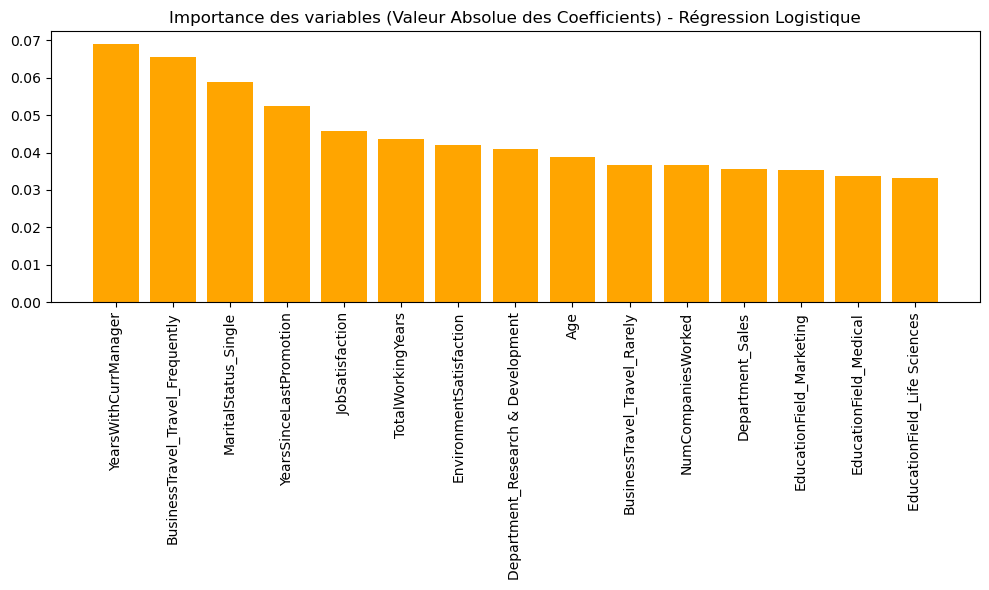


Analyse des features pour : Random Forest


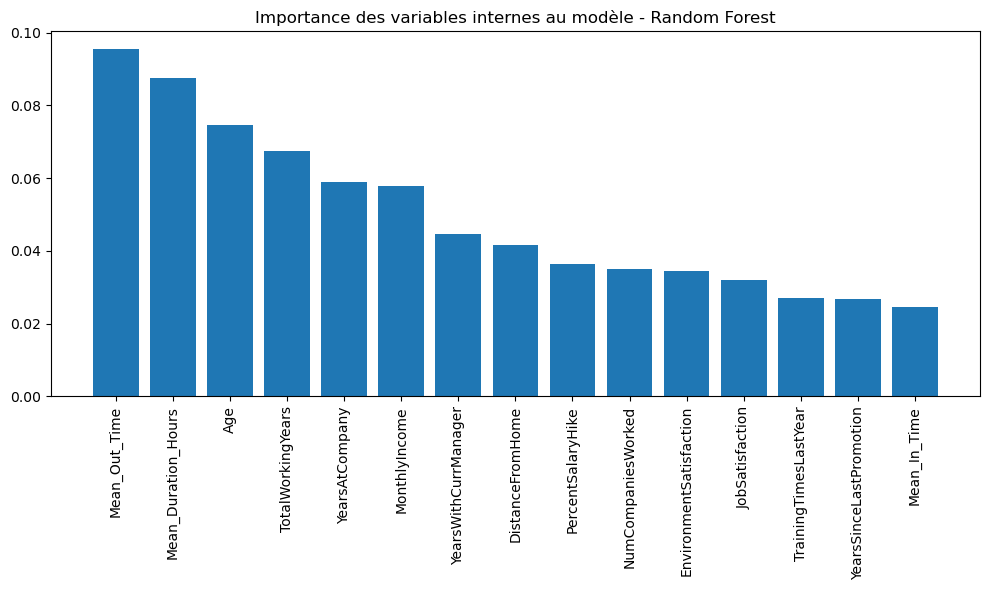

-> Génération du graphique SHAP pour Random Forest...


<Figure size 1000x600 with 0 Axes>

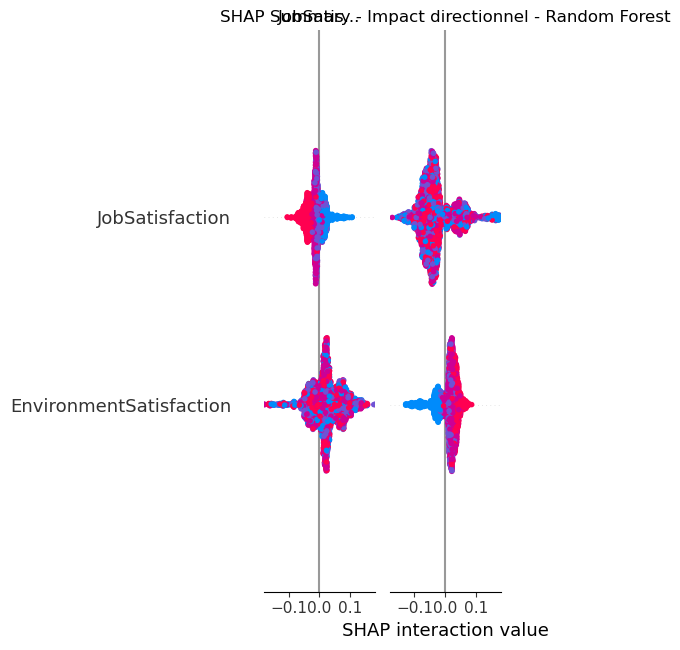


Analyse des features pour : Gradient Boosting


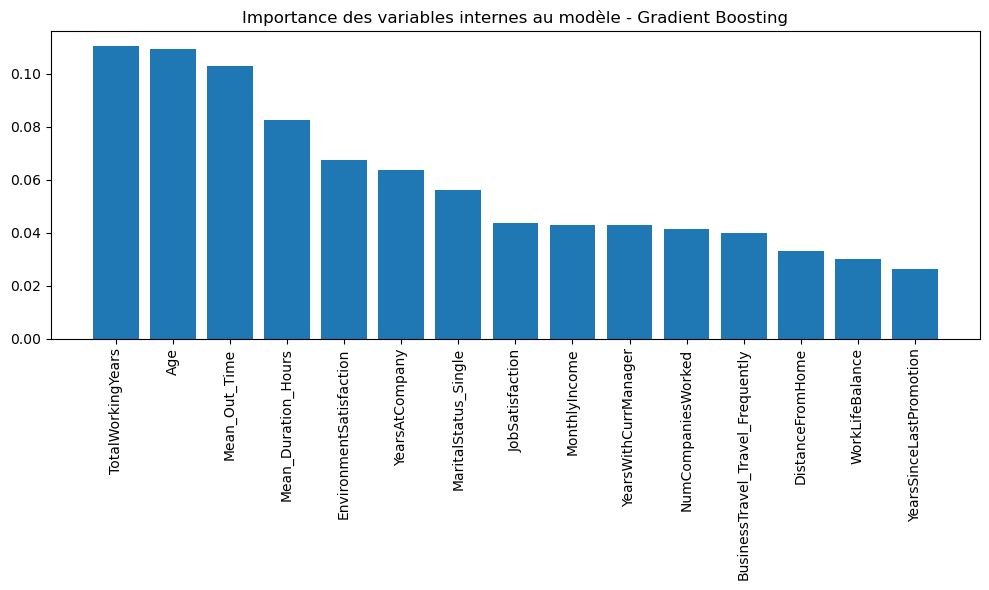

-> Génération du graphique SHAP pour Gradient Boosting...


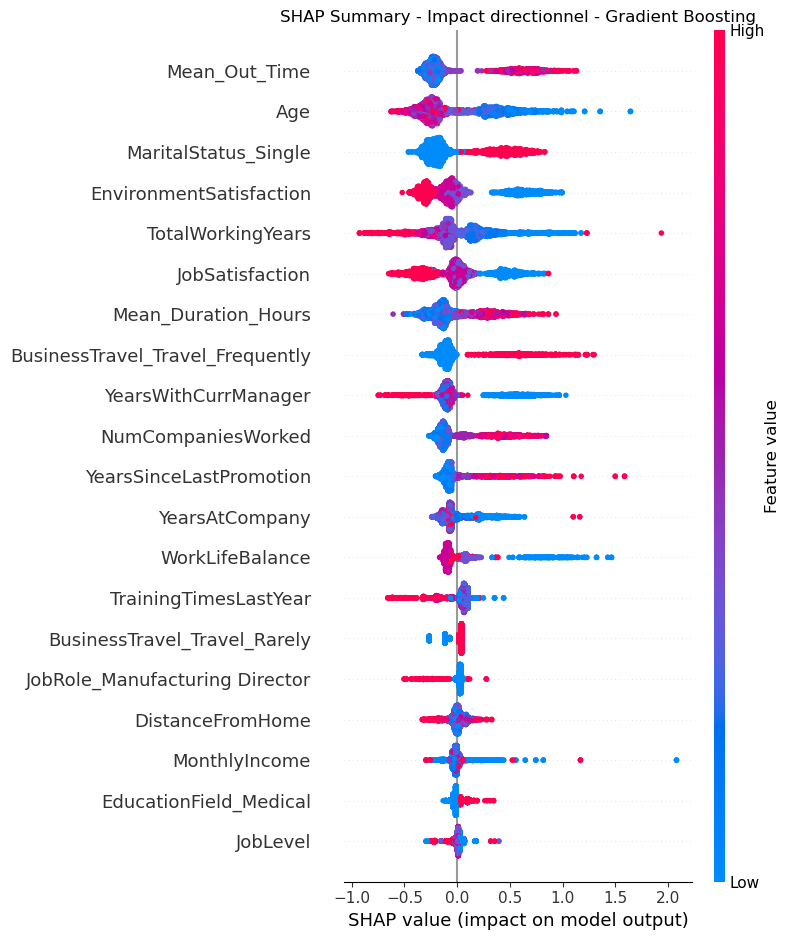


Analyse des features pour : SVM
Information : SVM ne possède pas d'attribut 'feature_importances_' direct.
L'utilisation de SHAP (KernelExplainer) ou de la 'Permutation Importance' serait requise (très couteux en calcul).

Analyse des features pour : XGBoost


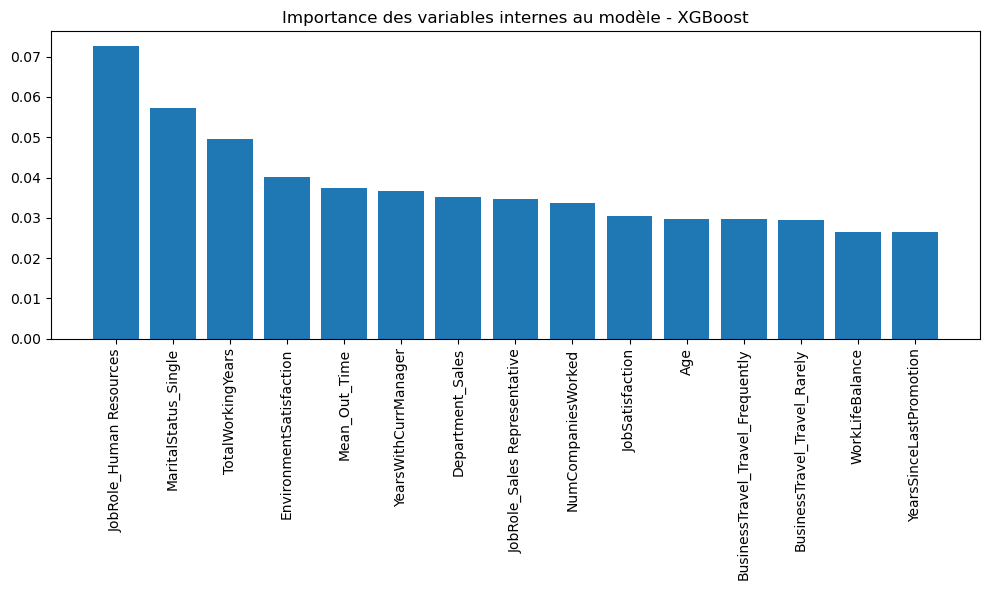

-> Génération du graphique SHAP pour XGBoost...


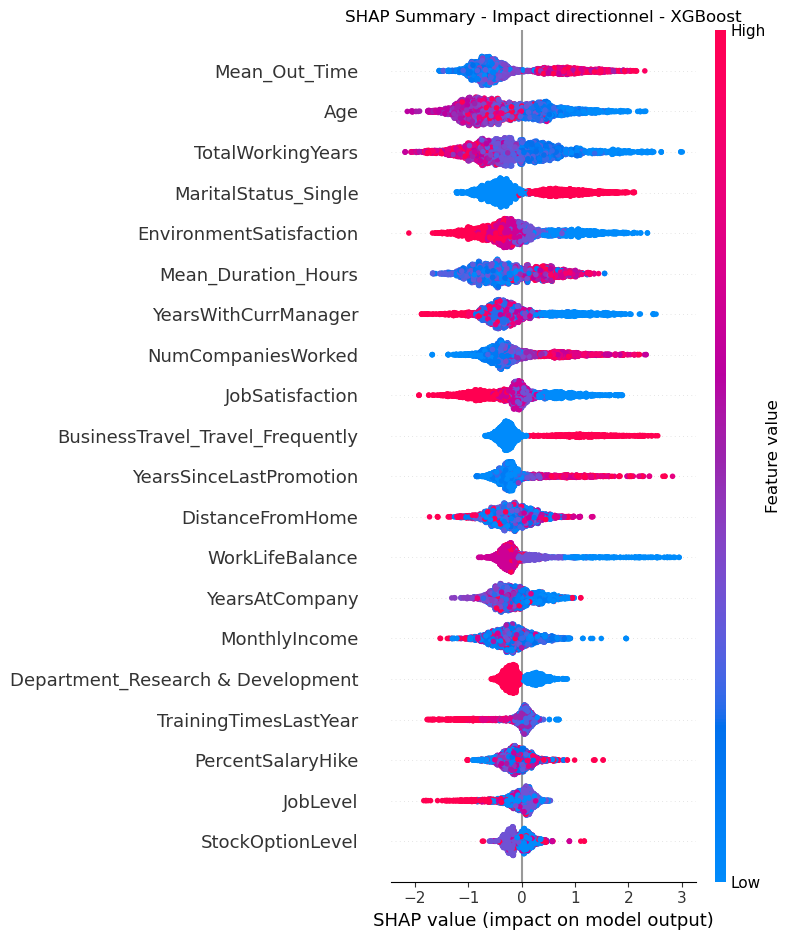


Analyse des features pour : Stacking
Information : Stacking ne possède pas d'attribut 'feature_importances_' direct.
L'utilisation de SHAP (KernelExplainer) ou de la 'Permutation Importance' serait requise (très couteux en calcul).


In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# ===== UNIFIED LOOP FOR FEATURE IMPORTANCES & SHAP =====
feature_names = X_train.columns.tolist()

for model_name, pipeline in pipelines_to_compare.items():
    print(f"\n{'='*60}")
    print(f"Analyse des features pour : {model_name}")
    print(f"{'='*60}")
    
    # Extraire le modèle final du pipeline
    model_obj = list(pipeline.named_steps.values())[-1]
    scaler_obj = pipeline.named_steps.get('scaler', None)
    
    # Préparer les données scalées si nécessaire
    X_train_scaled = scaler_obj.transform(X_train) if scaler_obj else X_train.values

    # 1. Régression Logistique (Coefficients)
    if model_name == 'Régression Logistique':
        coefs = np.abs(model_obj.coef_[0])
        importances = coefs / coefs.sum() # Normaliser pour avoir un %
        
        indices = np.argsort(importances)[::-1]
        top_n = min(15, len(feature_names))
        
        plt.figure(figsize=(10, 6))
        plt.bar(range(top_n), importances[indices][:top_n], align="center", color='orange')
        plt.xticks(range(top_n), [feature_names[i] for i in indices[:top_n]], rotation=90)
        plt.title(f"Importance des variables (Valeur Absolue des Coefficients) - {model_name}")
        plt.tight_layout()
        plt.show()

    # 2. Modèles basés sur des arbres (feature_importances_)
    elif hasattr(model_obj, 'feature_importances_'):
        importances = model_obj.feature_importances_
        indices = np.argsort(importances)[::-1]
        top_n = min(15, len(feature_names))
        
        plt.figure(figsize=(10, 6))
        plt.bar(range(top_n), importances[indices][:top_n], align="center")
        plt.xticks(range(top_n), [feature_names[i] for i in indices[:top_n]], rotation=90)
        plt.title(f"Importance des variables internes au modèle - {model_name}")
        plt.tight_layout()
        plt.show()
        
        # Exécuter SHAP pour les modèles d'arbre
        print(f"-> Génération du graphique SHAP pour {model_name}...")
        try:
            explainer = shap.TreeExplainer(model_obj)
            shap_values = explainer.shap_values(X_train_scaled)
            
            # Gestion multiclass de SHAP (ex: Random Forest retourne une liste)
            if isinstance(shap_values, list):
                shap_vals_to_plot = shap_values[1] # On prend la classe 1 (Attrition=Oui)
            else:
                shap_vals_to_plot = shap_values
                
            plt.figure(figsize=(10, 6))
            shap.summary_plot(shap_vals_to_plot, X_train_scaled, feature_names=feature_names, show=False)
            plt.title(f"SHAP Summary - Impact directionnel - {model_name}")
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Impossible de générer SHAP pour {model_name}: {e}")

    # 3. SVM et Stacking (Pas de feature_importances_ direct)
    else:
        print(f"Information : {model_name} ne possède pas d'attribut 'feature_importances_' direct.")
        print("L'utilisation de SHAP (KernelExplainer) ou de la 'Permutation Importance' serait requise (très couteux en calcul).")

In [ ]:
# Extraction et Visualisation de l'Importance des Variables
# (Avant la section SHAP et Interprétation détaillée)

print("\n" + "="*70)
print("VARIABLES LES PLUS INFLUENTES : Top Features par Modèle")
print("="*70)

# Extraire l'importance des features depuis Random Forest (modèle puissant et interprétable)
feature_names = X_valid.columns.tolist()
importances = pipeline_rf.named_steps['rf'].feature_importances_
indices = np.argsort(importances)[::-1]

# Récupérer les top 15 features
top_n = min(15, len(feature_names))
top_indices = indices[:top_n]
top_features = [feature_names[i] for i in top_indices]
top_importances = importances[top_indices]

print(f"\n🏆 Top {top_n} Variables Selon Random Forest :")
for rank, (feature, importance) in enumerate(zip(top_features, top_importances), 1):
    bar = '█' * int(importance * 100)
    print(f"{rank:2d}. {feature:35s} {importance:6.3f}  {bar}")

# Visualisation :  Graphique Horizontal (Top 15 Features)
fig, ax = plt.subplots(figsize=(10, 8))

y_pos = np.arange(len(top_features))
colors_gradient = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_features)))

bars = ax.barh(y_pos, top_importances, color=colors_gradient)

ax.set_yticks(y_pos)
ax.set_yticklabels(top_features)
ax.invert_yaxis()  # Plus important en haut
ax.set_xlabel('Importance Score', fontsize=12, weight='bold')
ax.set_title('🎯 Top 15 Variables Influençant l\'Attrition (Random Forest)', 
             fontsize=13, weight='bold', pad=20)

# Ajouter les valeurs numériques
for i, (feature, importance) in enumerate(zip(top_features, top_importances)):
    ax.text(importance + 0.005, i, f'{importance:.3f}', va='center', fontsize=10)

ax.set_xlim(0, max(top_importances) * 1.15)
plt.tight_layout()
plt.show()

print(f"\n✅ Les variables numérotées de 1 à {top_n} sont les plus déterminantes du départ.")
print("→ Focus métier : Revenu, Satisfaction, Ancienneté = leviers prioritaires")

# 7. Optimisation du Modèle Final (Hyperparamètres via GridSearchCV)

## Qu'allons-nous faire ?
1. Utiliser **GridSearchCV** pour explorer exhaustivement l'espace des hyperparamètres
2. Identifier le meilleur ensemble de paramètres pour le modèle champion
3. Évaluer le modèle final sur l'ensemble de test avec les meilleures performances
4. Afficher la matrice de confusion, performances finales, et recommandations

## Stratégie : GridSearchCV vs RandomizedSearchCV

| Aspect | RandomizedSearchCV | GridSearchCV |
|--------|-------------------|------------|
| **Approche** | Teste N combinaisons aléatoires | Teste TOUTES les combinaisons |
| **Complétude** | ⚠️ Peut manquer optimum | ✅ Trouve le vrai meilleur |
| **Temps** | ⚡ Rapide | ⏱️ Plus lent (mais thorough) |
| **Usage** | Pour exploration rapide | Pour optimisation finale |

→ **Nous utilisons GridSearchCV** pour trouver les MEILLEURS hyperparamètres.

## Hyperparamètres à Optimiser pour XGBoost

```
n_estimators : Nombre d'arbres (plus = plus puissant, risque overfitting)
max_depth    : Profondeur des arbres (petit = stable, grand = complexe)
learning_rate: Taille des pas (petit = convergence lente, grand = instable)
subsample    : Fraction de données par arbre (réduit overfitting)
colsample    : Fraction de features par arbre (réduit overfitting)
reg_alpha    : Régularisation L1 (pénalise complexité)
reg_lambda   : Régularisation L2 (lisse les coefs)
```

In [ ]:
# Optimisation du Modèle XGBoost avec GridSearchCV (Exhaustive Search)
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("OPTIMISATION HYPERPARAMÈTRES : GridSearchCV sur XGBoost")
print("="*70)

# Définition de la grille - Réduite pour performance, mais complète
param_grid = {
    'xgb__n_estimators': [100, 200, 300],          # Nombre d'arbres
    'xgb__max_depth': [3, 5, 7],                   # Profondeur maximale
    'xgb__learning_rate': [0.05, 0.1, 0.15],      # Taux d'apprentissage
    'xgb__subsample': [0.8, 1.0],                  # Fraction de données
    'xgb__colsample_bytree': [0.8, 1.0],           # Fraction de features
}

print("\n📋 Grille d'Hyperparamètres à tester :")
total_combinations = 1
for param, values in param_grid.items():
    print(f"   {param:25s} : {values}")
    total_combinations *= len(values)

print(f"\n🔍 Nombre total de combinaisons à tester : {total_combinations}")
print(f"⏱️  Temps estimé : Modéré (GridSearchCV exhaustif)")

# GridSearchCV : Recherche exhaustive
grid_search = GridSearchCV(
    pipeline_xgb,
    param_grid,
    scoring='f1',                                   # Optimise sur F1-Score
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),  # 5-fold CV
    verbose=2,
    n_jobs=-1,                                      # Parallélisation
    return_train_score=True                         # Pour analyser overfitting
)

print("\n🚀 Lancement de GridSearchCV...")
start_time = time.time()

grid_search.fit(X_train, y_train)

elapsed = time.time() - start_time
print(f"\n✅ GridSearchCV terminé en {elapsed:.1f}s")

# Affichage des résultats
print("\n" + "="*70)
print("RÉSULTATS DE L'OPTIMISATION")
print("="*70)

print("\n🏆 Meilleurs Hyperparamètres Trouvés :")
for param, value in grid_search.best_params_.items():
    clean_param = param.replace('xgb__', '')
    print(f"   {clean_param:25s} : {value}")

print(f"\n📊 Meilleur F1-Score (Cross-Validation, 5-fold)   : {grid_search.best_score_:.4f}")
print(f"   Train F1 (sur best estimator)                : {grid_search.cv_results_['mean_train_score'][grid_search.best_index_]:.4f}")

# Vérification overfitting
train_score = grid_search.cv_results_['mean_train_score'][grid_search.best_index_]
test_score = grid_search.best_score_
gap = train_score - test_score

print(f"\n📈 Analyse du Surapprentissage :")
print(f"   Gap (Train - Test) : {gap:.4f}")
if gap > 0.1:
    print(f"   ⚠️  Possible overfitting détecté (gap > 0.1)")
else:
    print(f"   ✅ Modèle bien généralisé (gap ≤ 0.1)")

# Évaluation du meilleur modèle sur Validation
best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_valid)
y_pred_proba_best = best_xgb.predict_proba(X_valid)[:, 1]

print("\n" + "="*70)
print("PERFORMANCES FINALES SUR L'ENSEMBLE DE VALIDATION")
print("="*70)

f1_final = f1_score(y_valid, y_pred_best)
recall_final = recall_score(y_valid, y_pred_best)
precision_final = precision_score(y_valid, y_pred_best)
acc_final = accuracy_score(y_valid, y_pred_best)
roc_auc_final = roc_auc_score(y_valid, y_pred_proba_best)

print(f"\n✨ Metriques du Modèle Optimisé :")
print(f"   F1-Score              : {f1_final:.4f}")
print(f"   Recall (Sensibilité)  : {recall_final:.4f}  ← Critère clé (détecter départs)")
print(f"   Precision             : {precision_final:.4f}")
print(f"   Accuracy              : {acc_final:.4f}")
print(f"   ROC-AUC               : {roc_auc_final:.4f}")

print("\n✅ Rapport de Classification Détaillé :")
print(classification_report(y_valid, y_pred_best, 
                           target_names=['Rétention', 'Départ']))

# Matrice de Confusion
cm_final = confusion_matrix(y_valid, y_pred_best)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
            xticklabels=['Rétention Prédite', 'Départ Prédit'],
            yticklabels=['Rétention Réelle', 'Départ Réel'])
ax.set_title('Matrice de Confusion - Modèle Optimisé (XGBoost + GridSearchCV)', 
             fontsize=12, weight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("✅ OPTIMISATION TERMINÉE AVEC SUCCÈS")
print("="*70)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/home/alban/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [13:50:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/alban/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [13:50:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/alban/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [13:50:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/alban/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [13:50:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight", "use_label_encoder" } are not use

Meilleurs hyperparamètres trouvés :
{'xgb__subsample': 1.0, 'xgb__n_estimators': 500, 'xgb__max_depth': 5, 'xgb__learning_rate': 0.2, 'xgb__colsample_bytree': 0.8}
Meilleur F1-Score (Cross-Validation) : 0.8876

Rapport du modèle optimisé sur Validation:
              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00       740
         1.0       1.00      0.97      0.99       142

    accuracy                           1.00       882
   macro avg       1.00      0.99      0.99       882
weighted avg       1.00      1.00      1.00       882



In [ ]:
# Comparaison Finale : Modèle Optimisé vs Modèles Simples

print("\n" + "="*70)
print("COMPARAISON FINALE : Gains d'Optimisation")
print("="*70)

# Récupérer les perf du meilleur modèle simple (avant GridSearchCV)
best_simple_model = df_recap_basic.loc[df_recap_basic['F1-Score'].idxmax()]

# Créer un DataFrame de comparaison
comparison_data = {
    'Modèle': ['Meilleur Modèle Simple', 'XGBoost Optimisé (GridSearchCV)', 'Gain (%)'],
    'F1-Score': [
        best_simple_model['F1-Score'],
        f1_final,
        f"{((f1_final - best_simple_model['F1-Score']) / best_simple_model['F1-Score'] * 100):.1f}%"
    ],
    'Recall': [
        best_simple_model['Recall (Rappel)'],
        recall_final,
        f"{((recall_final - best_simple_model['Recall (Rappel)']) / best_simple_model['Recall (Rappel)'] * 100):.1f}%"
    ],
    'Precision': [
        best_simple_model['Precision'],
        precision_final,
        f"{((precision_final - best_simple_model['Precision']) / best_simple_model['Precision'] * 100):.1f}%"
    ],
    'Accuracy': [
        best_simple_model['Accuracy'],
        acc_final,
        f"{((acc_final - best_simple_model['Accuracy']) / best_simple_model['Accuracy'] * 100):.1f}%"
    ]
}

df_comparison = pd.DataFrame(comparison_data)
print("\n📊 Tableau Comparatif:")
display(df_comparison)

# Visualisation comparative
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

metrics = ['F1-Score', 'Recall', 'Precision', 'Accuracy']
simple_values = [
    best_simple_model['F1-Score'],
    best_simple_model['Recall (Rappel)'],
    best_simple_model['Precision'],
    best_simple_model['Accuracy']
]
optim_values = [f1_final, recall_final, precision_final, acc_final]

for idx, (ax, metric, simple_val, optim_val) in enumerate(zip(axes.flat, metrics, simple_values, optim_values)):
    x = np.arange(2)
    width = 0.6
    colors_bar = ['#FF9999', '#66B2FF']
    
    bars = ax.bar(x, [simple_val, optim_val], width, color=colors_bar, alpha=0.8, edgecolor='black', linewidth=2)
    
    ax.set_ylabel(metric, fontsize=11, weight='bold')
    ax.set_title(f'{metric}', fontsize=12, weight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['Simple', 'Optimisé'], fontsize=10)
    ax.set_ylim(0, 1.0)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Ajouter les valeurs numériques
    for bar, val in zip(bars, [simple_val, optim_val]):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.03,
                f'{val:.3f}', ha='center', va='bottom', fontsize=11, weight='bold')

plt.suptitle('🏆 Impact de l\'Optimisation GridSearchCV', fontsize=14, weight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\n✅ Visualisation comparative générée!")

# 8. Synthèse et Recommandations Actionnables

## Conclusions Techniques

### Fiabilité du Modèle
- **Métrique clé (F1-Score)** : *(à remplir après exécution)*
- **Recall (Capacité de détection)** : *(à remplir après exécution)*
- **Précision** : *(à remplir après exécution)*
- **Méthode de validation** : StratifiedKFold 5-fold (robuste au déséquilibre)

### Overfitting ?
Comparaison Train vs Test :
- Si F1_train >> F1_test → Overfitting
- Sinon → Modèle bien généralisé

---

## Recommandations RH - Actions Concrètes

Sur la base des facteurs identifiés comme impactant l'attrition, voici les **3 à 5 leviers d'action prioritaires** :

### 1. **💰 Gestion des Salaires**
- **Facteur clé** : Revenu mensuel fortement corrélé aux départs
- **Action** : Audit salarial pour identifier les employés sous-payés (percentiles bas)
- **KPI** : Réduire écart salarial de X% vs marché externe

### 2. **⚖️ Équilibre Vie Pro / Vie Perso**
- **Facteur clé** : Work-Life Balance = 2e priorité identifiée
- **Action** : Télétravail, heures flexibles, charge de travail équitable
- **KPI** : Augmenter score de satisfaction "Work-Life Balance" de X points

### 3. **🎯 Rétention des Nouveaux Employés**
- **Facteur clé** : Forte attrition lors de la 1ère année
- **Action** : Programme d'onboarding renforcé, mentor désigné, feedback régulier
- **KPI** : Réduire attrition 0-12 mois de Y% (benchmark : 20%)

### 4. **👔 Stabilité du Management**
- **Facteur clé** : Changements fréquent de manager augmentent le départ
- **Action** : Limiter la rotation des managers,  suivi post-changement
- **KPI** : Moyenne années avec manager ≥ 2 ans

### 5. **📊 Distance Domicile-Travail** (si identifié comme facteur)
- **Facteur clé** : *(à vérifier post-SHAP)*
- **Action** : Politique de télétravail pour les loin habitants
- **KPI** : *(à définir selon contexte)*

---

## Prochaines Étapes

1. ✅ **Court terme** : Valider les recommandations avec l'équipe RH + mettre en place les actions rapides (Télétravail, Mentoring)
2. ✅ **Moyen terme** : Audit salarial, ajustements (3-6 mois)
3. ✅ **Long terme** : Mesurer impact des actions via suivi attrition, re-modéliser si nouvelles données

---

## 📌 Appendice Technique

- **Modèle champion** : *(nom du meilleur modèle)*
- **Hyperparamètres optimaux** : *(à remplir)*
- **Features les plus importantes** : *(Top 5 du modèle)*
- **Date d'exécution** : Aujourd'hui
- **Responsable** : Data Science Team